<h3 style="font-family: 'Times New Roman'; color: red;"><b>1. Import Libraries and Load Data</b>
    
</h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Load the cleaned dataset from NB01 and confirm it has 46,667 rows, 25 columns, and all expected columns including the anomaly flags.</b></i>
</p>

------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
import pandas as pd
sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'figure.facecolor': '#fafaf8',
    'axes.facecolor':   '#fafaf8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})
ACCENT = '#c84b1e'
BLUE   = '#1a5fa8'
GREEN  = '#1a6b3f'
AMBER  = '#d68910'

palette = {
    'Elite':        '#E24B4A',
    'Upper Middle': '#BA7517',
    'Middle Class': '#378ADD',
    'Affordable':   '#1D9E75',
    'Other':        '#999999',
}


In [3]:
df=pd.read_csv('data/preprocessed/all_listings_with_flags.csv',parse_dates=['date_added'])

In [4]:
print(f"Shape : {df.shape}")
print(f"Rows : {len(df):,}")
print(f"Columns : {df.shape[1]}")
print("Column list:")
df.columns.to_list()

Shape : (46667, 25)
Rows : 46,667
Columns : 25
Column list:


['property_id',
 'page_url',
 'property_type',
 'price',
 'location',
 'latitude',
 'longitude',
 'baths',
 'area',
 'bedrooms',
 'date_added',
 'area_sqft',
 'relisting_count',
 'unique_url_count',
 'relisting_span_days',
 'ghost_listing_flag',
 'year_week',
 'listings_per_week_in_area',
 'lat_anomaly',
 'lon_anomaly',
 'geo_anomaly',
 'price_too_low_flag',
 'price_very_high_flag',
 'suspicious_flag_count',
 'is_suspicious']

<h3 style="font-family: 'Times New Roman'; color: red;">
<b>2. Univariate Analysis</b>
    
</h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Understand the distribution of each individual column
before analyzing relationships between columns.</b></i>
</p>

------

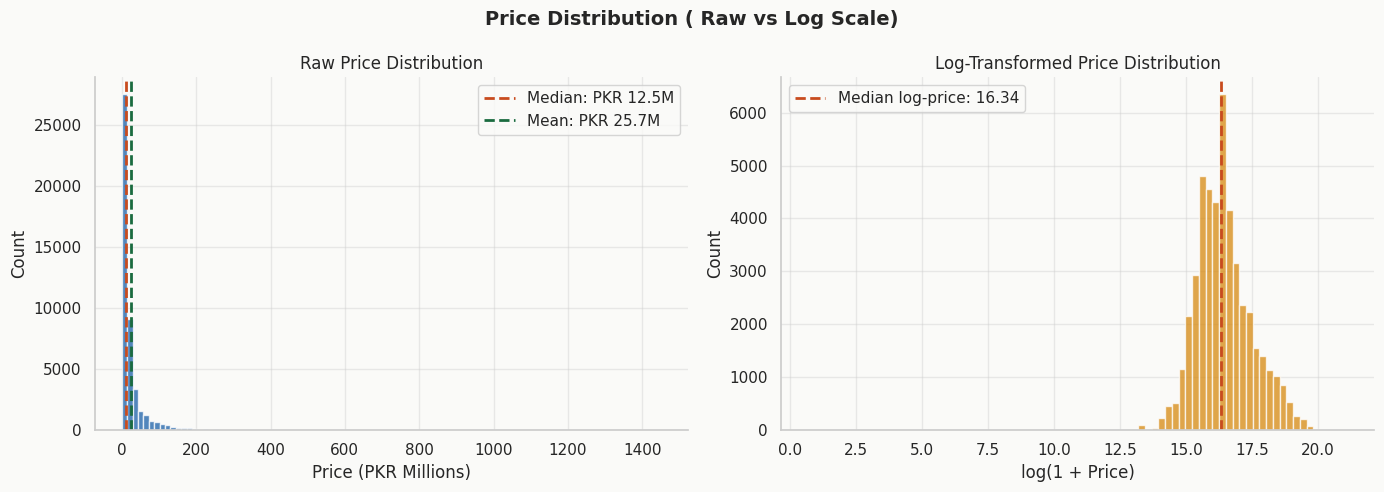

In [5]:
# 4.1 — Price distribution: raw and log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution ( Raw vs Log Scale)', fontsize=14, fontweight='bold')

# Raw
axes[0].hist(df['price'] / 1e6, bins=100, color=BLUE, alpha=0.75, edgecolor='white')
axes[0].axvline(df['price'].median() / 1e6, color=ACCENT, linestyle='--', lw=2,
                label=f"Median: PKR {df['price'].median()/1e6:.1f}M")
axes[0].axvline(df['price'].mean() / 1e6, color=GREEN, linestyle='--', lw=2,
                label=f"Mean: PKR {df['price'].mean()/1e6:.1f}M")
axes[0].set_xlabel('Price (PKR Millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Price Distribution')
axes[0].legend()

# Log
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=80, color=AMBER, alpha=0.75, edgecolor='white')
axes[1].axvline(log_price.median(), color=ACCENT, linestyle='--', lw=2,
                label=f"Median log-price: {log_price.median():.2f}")
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/eda_uni_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
skew = df['price'].skew()
kurt = df['price'].kurt()
print(f"Price skewness : {skew:.2f}  (>1 = significantly right-skewed)")
print(f"Price kurtosis : {kurt:.2f}  (>3 = heavy tails)")

Price skewness : 5.86  (>1 = significantly right-skewed)
Price kurtosis : 82.84  (>3 = heavy tails)


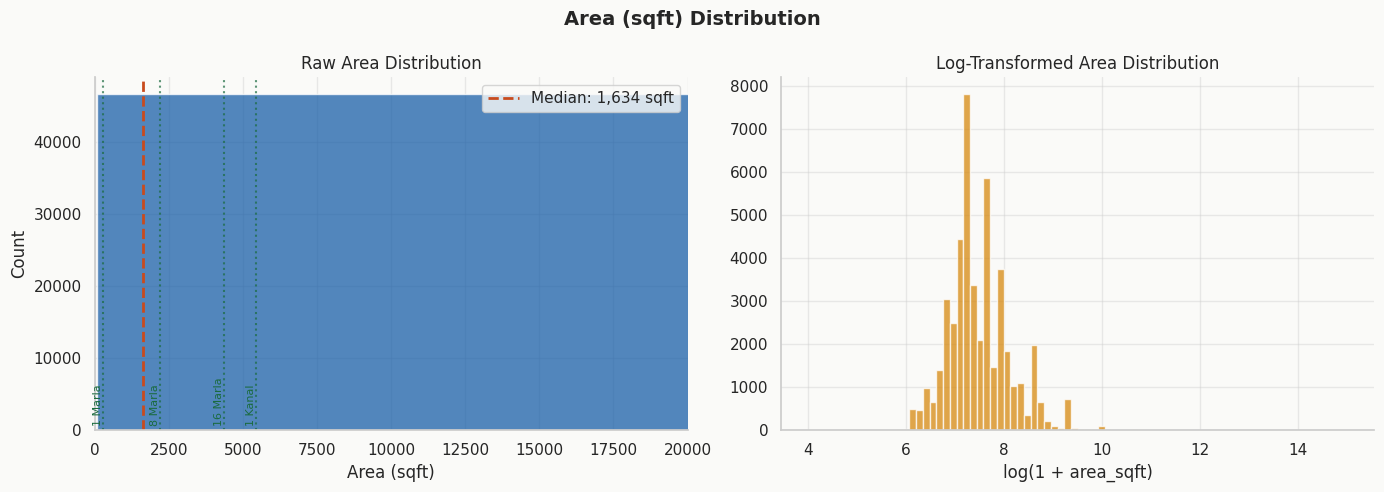

In [7]:
# 4.2 — Area distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Area (sqft) Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['area_sqft'], bins=100, color=BLUE, alpha=0.75, edgecolor='white')
axes[0].axvline(df['area_sqft'].median(), color=ACCENT, linestyle='--', lw=2,
                label=f"Median: {df['area_sqft'].median():,.0f} sqft")
# Mark standard Pakistani sizes
for size, label in [(272.25, '1 Marla'), (2178, '8 Marla'), (4356, '16 Marla'), (5445, '1 Kanal')]:
    axes[0].axvline(size, color=GREEN, linestyle=':', lw=1.5, alpha=0.7)
    axes[0].text(size, axes[0].get_ylim()[1]*0.01, label, rotation=90,
                 va='bottom', ha='right', fontsize=8, color=GREEN)
axes[0].set_xlabel('Area (sqft)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Area Distribution')
axes[0].legend()
axes[0].set_xlim(0, 20000)

axes[1].hist(np.log1p(df['area_sqft']), bins=80, color=AMBER, alpha=0.75, edgecolor='white')
axes[1].set_xlabel('log(1 + area_sqft)')
axes[1].set_title('Log-Transformed Area Distribution')

plt.tight_layout()
plt.savefig('reports/figures/eda_uni_area_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f"Area skewness : {df['area_sqft'].skew():.2f}")
print("Key multimodal peaks (standard Pakistani plot sizes):")
for p, label in [(272.25,'1 Marla'), (2178,'8 Marla'), (4356,'16 Marla'), (5445,'1 Kanal')]:
    near = df[(df['area_sqft'] >= p*0.95) & (df['area_sqft'] <= p*1.05)]
    print(f"  {label:10s} (~{p:.0f} sqft): {len(near):,} listings  ({len(near)/len(df)*100:.1f}%)")

Area skewness : 198.44
Key multimodal peaks (standard Pakistani plot sizes):
  1 Marla    (~272 sqft): 2 listings  (0.0%)
  8 Marla    (~2178 sqft): 5,928 listings  (12.7%)
  16 Marla   (~4356 sqft): 1,021 listings  (2.2%)
  1 Kanal    (~5445 sqft): 1,981 listings  (4.2%)


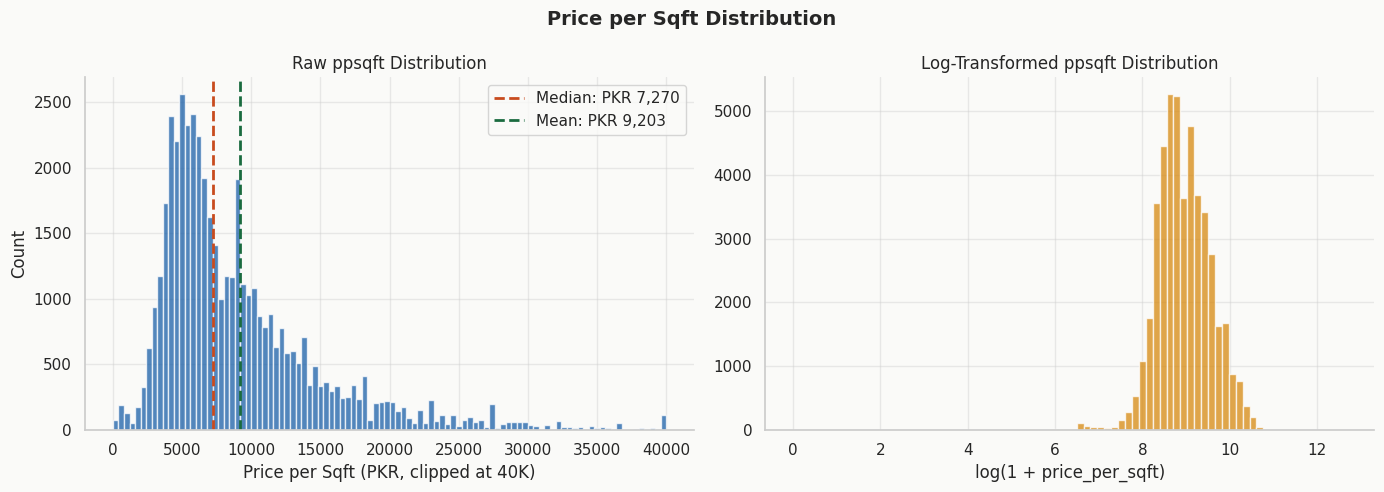

In [9]:
# 4.3 — Price per sqft distribution
price_per_sqft= df['price'] / df['area_sqft']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price per Sqft Distribution', fontsize=14, fontweight='bold')

axes[0].hist(price_per_sqft.clip(0, 40000), bins=100, color=BLUE, alpha=0.75, edgecolor='white')
axes[0].axvline(price_per_sqft.median(), color=ACCENT, linestyle='--', lw=2,
                label=f"Median: PKR {price_per_sqft.median():,.0f}")
axes[0].axvline(price_per_sqft.mean(), color=GREEN, linestyle='--', lw=2,
                label=f"Mean: PKR {price_per_sqft.mean():,.0f}")
axes[0].set_xlabel('Price per Sqft (PKR, clipped at 40K)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw ppsqft Distribution')
axes[0].legend()

axes[1].hist(np.log1p(price_per_sqft), bins=80, color=AMBER, alpha=0.75, edgecolor='white')
axes[1].set_xlabel('log(1 + price_per_sqft)')
axes[1].set_title('Log-Transformed ppsqft Distribution')

plt.tight_layout()
plt.savefig('reports/figures/eda_uni_ppsqft_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print(f"ppsqft skewness : {price_per_sqft.skew():.2f}")

ppsqft skewness : 6.23


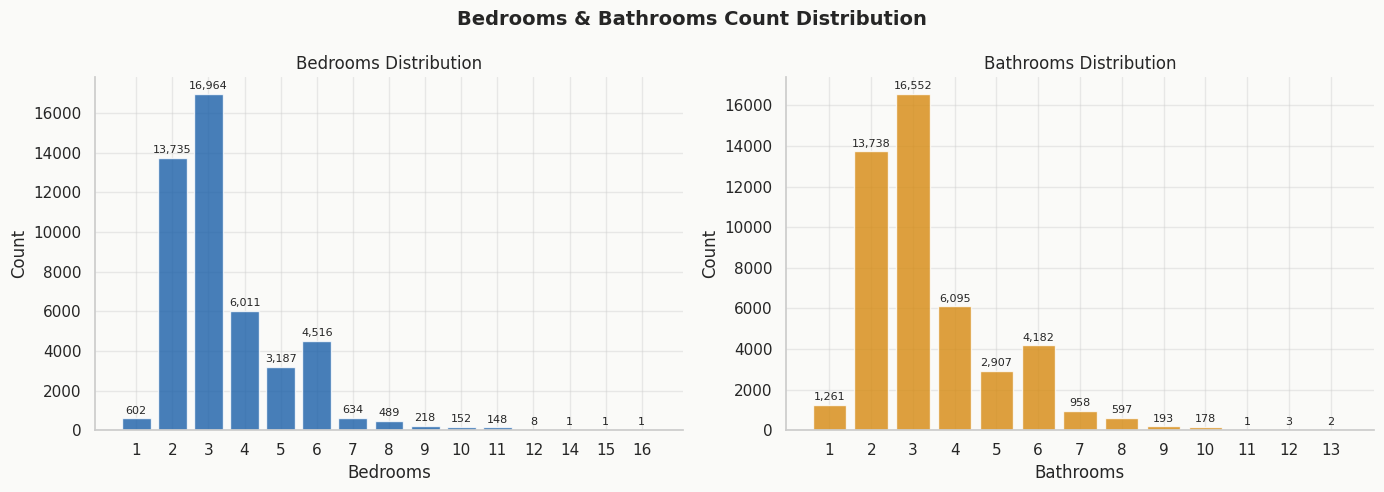

In [11]:
# 4.4 — Discrete variables: bedrooms and baths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bedrooms & Bathrooms Count Distribution', fontsize=14, fontweight='bold')

for ax, col, color, title in [
    (axes[0], 'bedrooms', BLUE,  'Bedrooms'),
    (axes[1], 'baths',    AMBER, 'Bathrooms'),
]:
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values, color=color, alpha=0.8, edgecolor='white')
    ax.bar_label(bars, fmt='{:,.0f}', padding=2, fontsize=8)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Distribution')

plt.tight_layout()
plt.savefig('reports/figures/eda_uni_bedrooms_baths.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("Bedroom distribution:")
print(df['bedrooms'].value_counts().sort_index().to_string())
print()
print("Bath distribution:")
print(df['baths'].value_counts().sort_index().to_string())

Bedroom distribution:
bedrooms
1       602
2     13735
3     16964
4      6011
5      3187
6      4516
7       634
8       489
9       218
10      152
11      148
12        8
14        1
15        1
16        1

Bath distribution:
baths
1      1261
2     13738
3     16552
4      6095
5      2907
6      4182
7       958
8       597
9       193
10      178
11        1
12        3
13        2


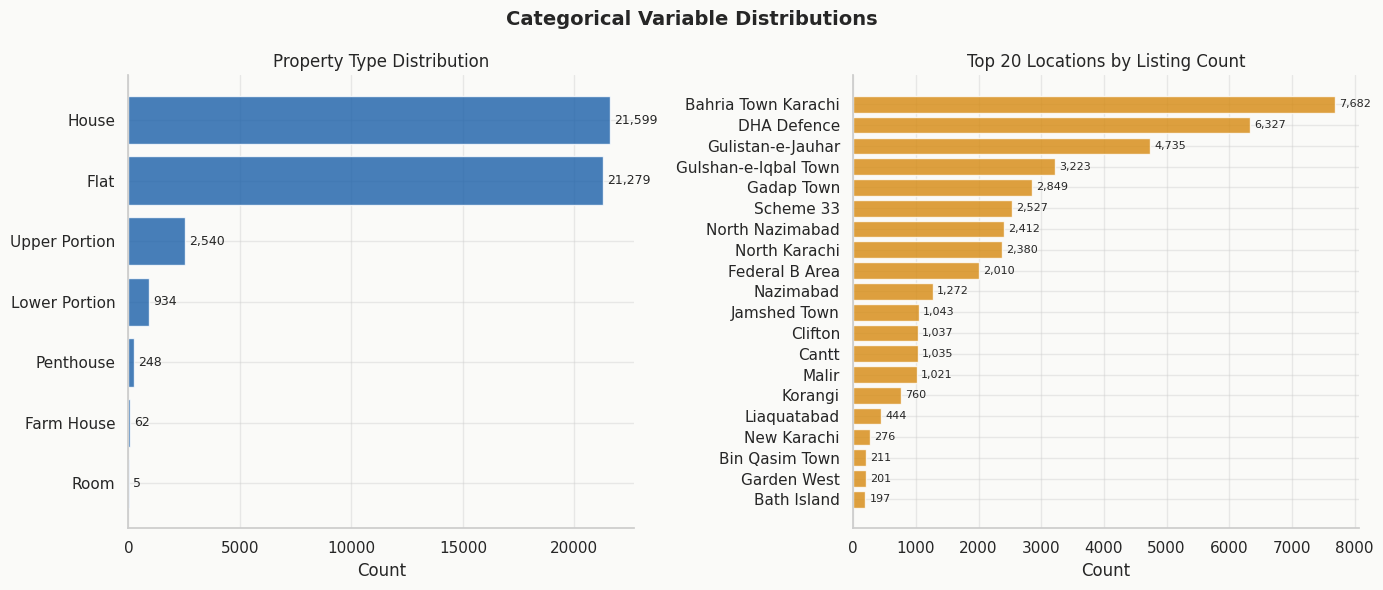

In [13]:
 # 4.5 — Categorical variables: property type and location
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold')

# Property type
pt_counts = df['property_type'].value_counts()
bars = axes[0].barh(pt_counts.index[::-1], pt_counts.values[::-1], color=BLUE, alpha=0.8)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title('Property Type Distribution')

# Top 20 locations
loc_counts = df['location'].value_counts().head(20)
bars2 = axes[1].barh(loc_counts.index[::-1], loc_counts.values[::-1], color=AMBER, alpha=0.8)
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=3, fontsize=8)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 20 Locations by Listing Count')

plt.tight_layout()
plt.savefig('reports/figures/eda_uni_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
print(f"Unique property types: {df['property_type'].nunique()}")
print(f"Unique locations     : {df['location'].nunique()}")

Unique property types: 7
Unique locations     : 197


<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Price is heavily right-skewed</b> (skewness > 5). Mean is nearly double the median.
This directly justifies using <b>RobustScaler</b> in FE  instead of StandardScaler,
and motivates <b>IQR-based deviation features</b> as a more robust alternative to z-scores.</li>
<li><b>Area distribution is multimodal</b> which peaks at standard Pakistani plot sizes (8 Marla, 16 Marla, 1 Kanal).
This confirms area comparisons must be done <b>within location groups</b>, not globally,
motivating the <b>group-wise z-score and IQR features</b> in FE Section 3 & 4.</li>
<li><b>Price-per-sqft</b> is the most informative single derived column for market comparison which is 
confirmed by the tight, meaningful distribution. Its <b>location-wise IQR deviation</b>
(ppsqft_iqr_deviation) is the single strongest anomaly signal in the FE feature set.</li>
<li><b>Discrete bedroom/bath distributions</b> show clear expected peaks at 2, 3, 4 bedrooms.
Any listing with an unusual bath-to-bedroom ratio will stand out which motivating <b>bath_bed_ratio</b>
and <b>bath_bed_extreme</b> flags in FE </li>
<li><b>Location cardinality is high</b> (~200 unique locations) → LabelEncoder is correct.
Property type has low cardinality (7 types) → OneHotEncoder is correct.
These choices are confirmed by this section, not assumed.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;">
<b>2. Bivariate Analysis</b>
</h3>

------------------
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Analyze relationships between two variables to understand
what drives property prices across Karachi.</b></i>
</p>

----

In [15]:
# 5.1 — Median price per sqft by location (all locations with 50+ listings)
reliable = (df.groupby('location').filter(lambda x: len(x) >= 50))
reliable = reliable.assign(price_per_sqft=reliable['price'] / reliable['area_sqft'])
loc_stats = (reliable.groupby('location')
             .agg(
                 median_ppsqft  = ('price_per_sqft', 'median'),
                 std_ppsqft     = ('price_per_sqft', 'std'),
                 listing_count  = ('price', 'count'),
                 median_price   = ('price', 'median'),
             )
             .reset_index()
             .sort_values('median_ppsqft', ascending=False))


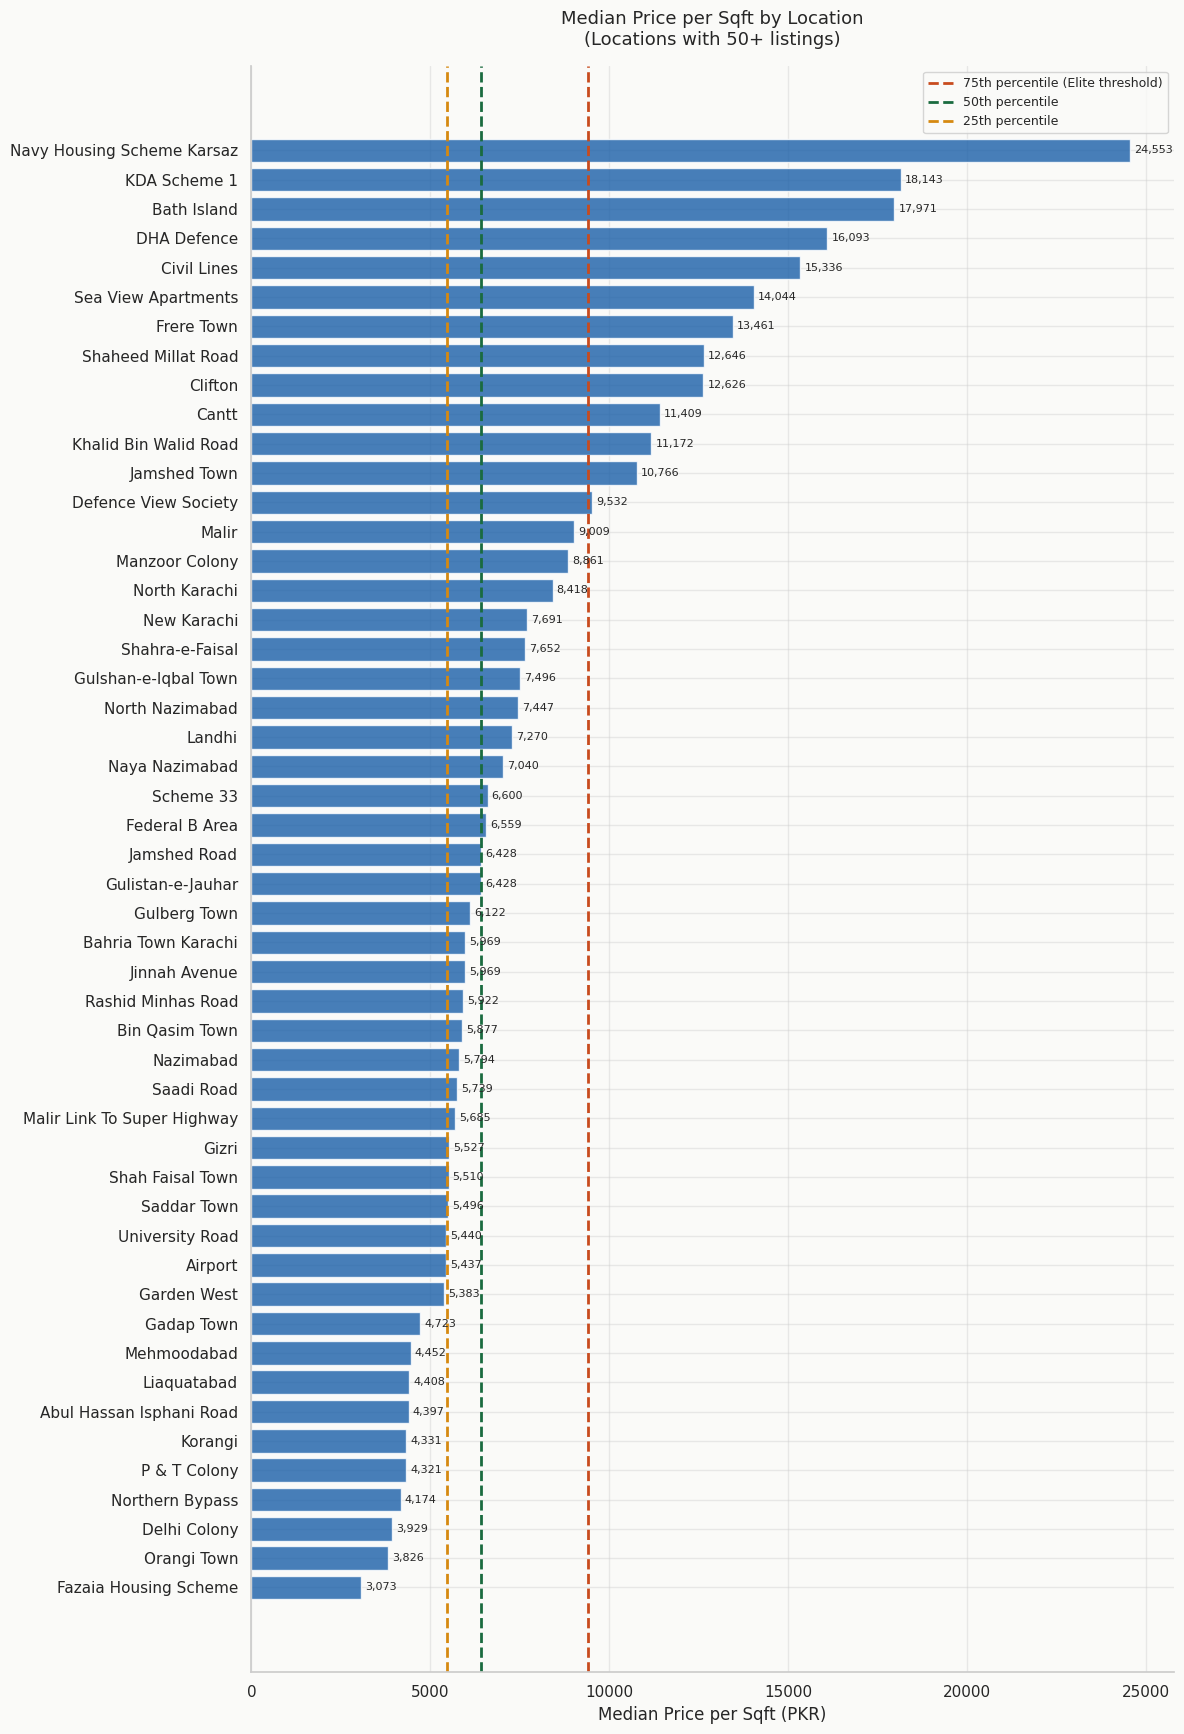

In [16]:
fig, ax = plt.subplots(figsize=(12, max(6, len(loc_stats)*0.35)))
bars = ax.barh(loc_stats['location'][::-1], loc_stats['median_ppsqft'][::-1],
               color=BLUE, alpha=0.8, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
ax.set_xlabel('Median Price per Sqft (PKR)')
ax.set_title('Median Price per Sqft by Location\n(Locations with 50+ listings)',
             fontsize=13, pad=15)
ax.axvline(loc_stats['median_ppsqft'].quantile(0.75), color=ACCENT, linestyle='--',
           lw=2, label='75th percentile (Elite threshold)')
ax.axvline(loc_stats['median_ppsqft'].median(), color=GREEN, linestyle='--',
           lw=2, label='50th percentile')
ax.axvline(loc_stats['median_ppsqft'].quantile(0.25), color=AMBER, linestyle='--',
           lw=2, label='25th percentile')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/eda_bi_ppsqft_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("Price tier cut-points (used in FE market_tier_derived):")
print(f"  Elite threshold  (p75): PKR {loc_stats['median_ppsqft'].quantile(0.75):,.0f}/sqft")
print(f"  Upper Mid        (p50): PKR {loc_stats['median_ppsqft'].median():,.0f}/sqft")
print(f"  Middle Class     (p25): PKR {loc_stats['median_ppsqft'].quantile(0.25):,.0f}/sqft")

Price tier cut-points (used in FE market_tier_derived):
  Elite threshold  (p75): PKR 9,402/sqft
  Upper Mid        (p50): PKR 6,428/sqft
  Middle Class     (p25): PKR 5,454/sqft


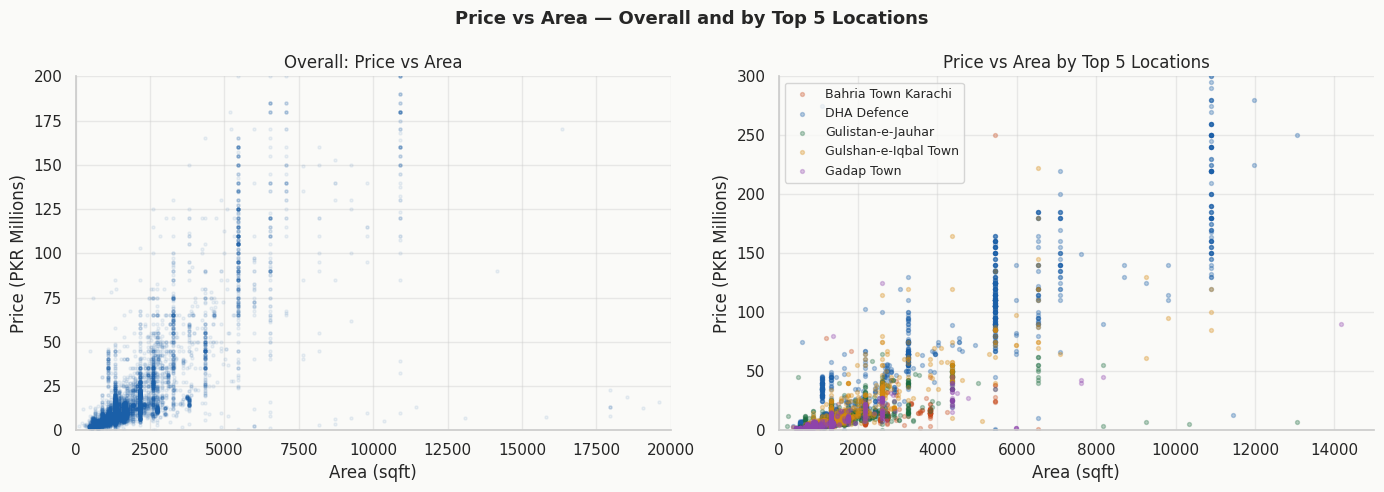

In [18]:
# 5.2 — Price vs Area scatter: confirm linear relationship and location-driven intercept
sample = df.sample(n=min(8000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price vs Area — Overall and by Top 5 Locations', fontsize=13, fontweight='bold')

# Overall scatter
axes[0].scatter(sample['area_sqft'], sample['price'] / 1e6,
                alpha=0.07, s=5, color=BLUE)
axes[0].set_xlabel('Area (sqft)')
axes[0].set_ylabel('Price (PKR Millions)')
axes[0].set_title('Overall: Price vs Area')
axes[0].set_xlim(0, 20000)
axes[0].set_ylim(0, 200)

# By top 5 location
top5_locs = df['location'].value_counts().head(5).index.tolist()
colors = [ACCENT, BLUE, GREEN, AMBER, '#8e44ad']
for loc, color in zip(top5_locs, colors):
    sub = sample[sample['location'] == loc]
    axes[1].scatter(sub['area_sqft'], sub['price'] / 1e6,
                    alpha=0.3, s=8, color=color, label=loc)
axes[1].set_xlabel('Area (sqft)')
axes[1].set_ylabel('Price (PKR Millions)')
axes[1].set_title('Price vs Area by Top 5 Locations')
axes[1].set_xlim(0, 15000)
axes[1].set_ylim(0, 300)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('reports/figures/eda_bi_price_vs_area.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
overall_r = df['price'].corr(df['area_sqft'])
print(f"Overall Pearson r (price vs area_sqft): {overall_r:.4f}")
print("Although the overall Pearson correlation between price and area is weak (r = 0.1125), this result is heavily influenced by location-driven price differences across Karachi. Premium areas such as DHA and Clifton command substantially higher prices regardless of size, reducing the strength of the global relationship. Within individual locations, the relationship between area and price is expected to be considerably stronger.")

Overall Pearson r (price vs area_sqft): 0.1125
Although the overall Pearson correlation between price and area is weak (r = 0.1125), this result is heavily influenced by location-driven price differences across Karachi. Premium areas such as DHA and Clifton command substantially higher prices regardless of size, reducing the strength of the global relationship. Within individual locations, the relationship between area and price is expected to be considerably stronger.


In [20]:
top_locations = df['location'].value_counts().head(10).index

for loc in top_locations:
    subset = df[df['location'] == loc]

    corr = subset['price'].corr(
        subset['area_sqft'],
        method='spearman'
    )

    print(loc, corr)

Bahria Town Karachi 0.5179417379910027
DHA Defence 0.9084114471470651
Gulistan-e-Jauhar 0.7768723225065258
Gulshan-e-Iqbal Town 0.8309929183296313
Gadap Town 0.8460256749597341
Scheme 33 0.7779924900223301
North Nazimabad 0.8866669430230694
North Karachi 0.6789187252755944
Federal B Area 0.8145862571925256
Nazimabad 0.827759096583351


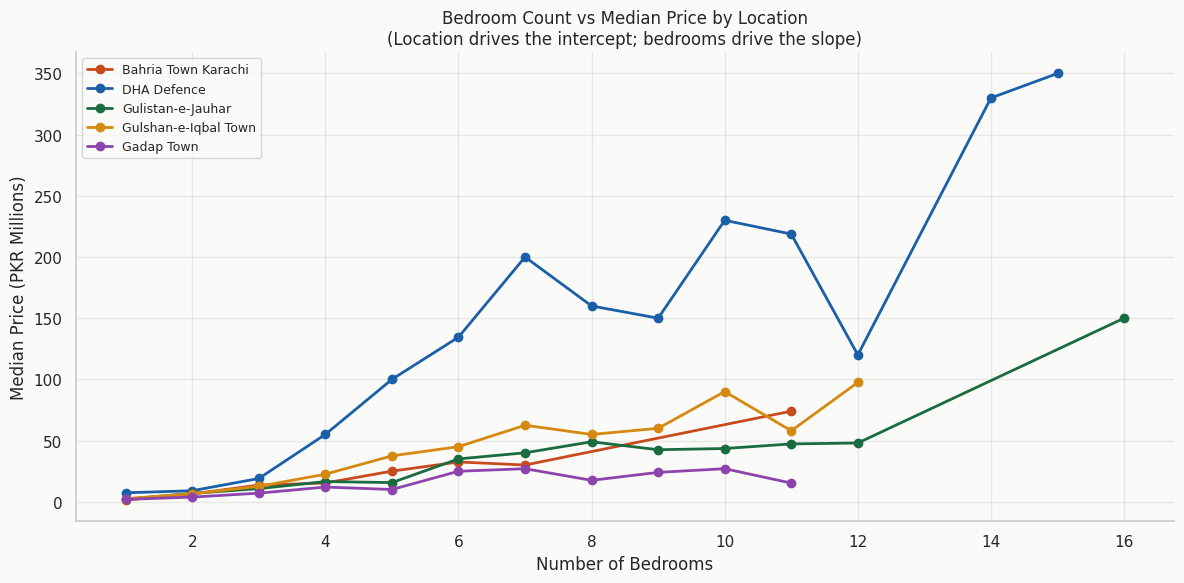

In [21]:
# 5.3 — Bedroom count vs median price by location
# Confirms that price premium per bedroom varies by location — motivating price_vs_expected_ratio
top5_locs = df['location'].value_counts().head(5).index.tolist()

bed_price = (df[df['location'].isin(top5_locs)]
             .groupby(['location', 'bedrooms'])['price']
             .median()
             .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT, BLUE, GREEN, AMBER, '#8e44ad']
for loc, color in zip(top5_locs, colors):
    sub = bed_price[bed_price['location'] == loc]
    ax.plot(sub['bedrooms'], sub['price'] / 1e6,
            marker='o', linewidth=2, color=color, label=loc)

ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Median Price (PKR Millions)')
ax.set_title('Bedroom Count vs Median Price by Location\n(Location drives the intercept; bedrooms drive the slope)',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/eda_bi_bedrooms_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

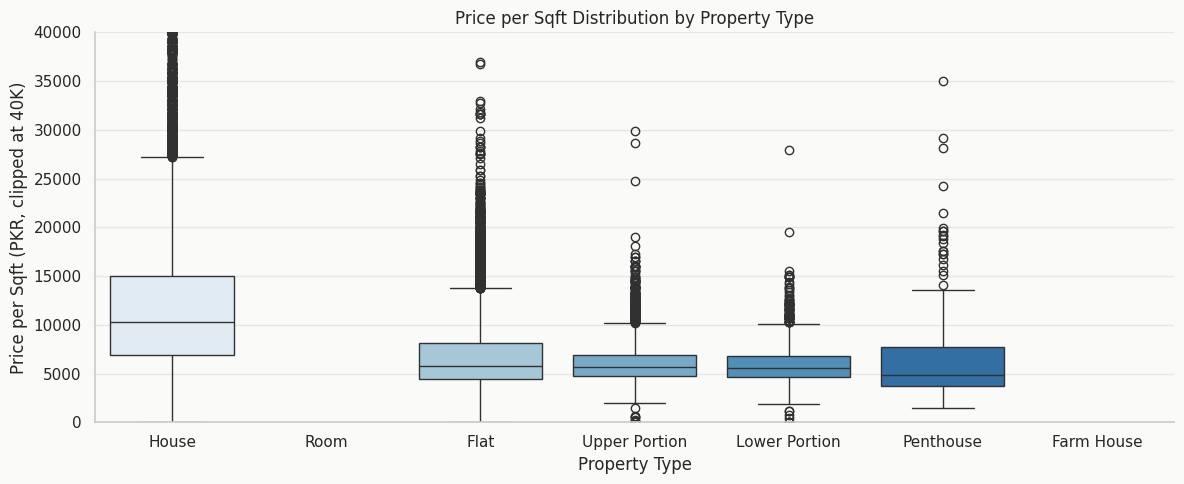

In [22]:
# 5.4 — Price per sqft by property type (box plot)
fig, ax = plt.subplots(figsize=(12, 5))
price_per_sqft=df['price']/df['area_sqft']
pt_order = (df.groupby('property_type')['price']
              .apply(lambda x: (x / df.loc[x.index, 'area_sqft']).median())
              .sort_values(ascending=False)
              .index.tolist())

df_box = df[df['property_type'].isin(
    df['property_type'].value_counts()[lambda x: x >= 100].index
)]

sns.boxplot(data=df_box.assign(price_per_sqft=price_per_sqft.loc[df_box.index]), x='property_type', y='price_per_sqft',
            order=pt_order, palette='Blues', ax=ax)
ax.set_ylim(0, 40000)
ax.set_xlabel('Property Type')
ax.set_ylabel('Price per Sqft (PKR, clipped at 40K)')
ax.set_title('Price per Sqft Distribution by Property Type', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/eda_bi_ppsqft_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

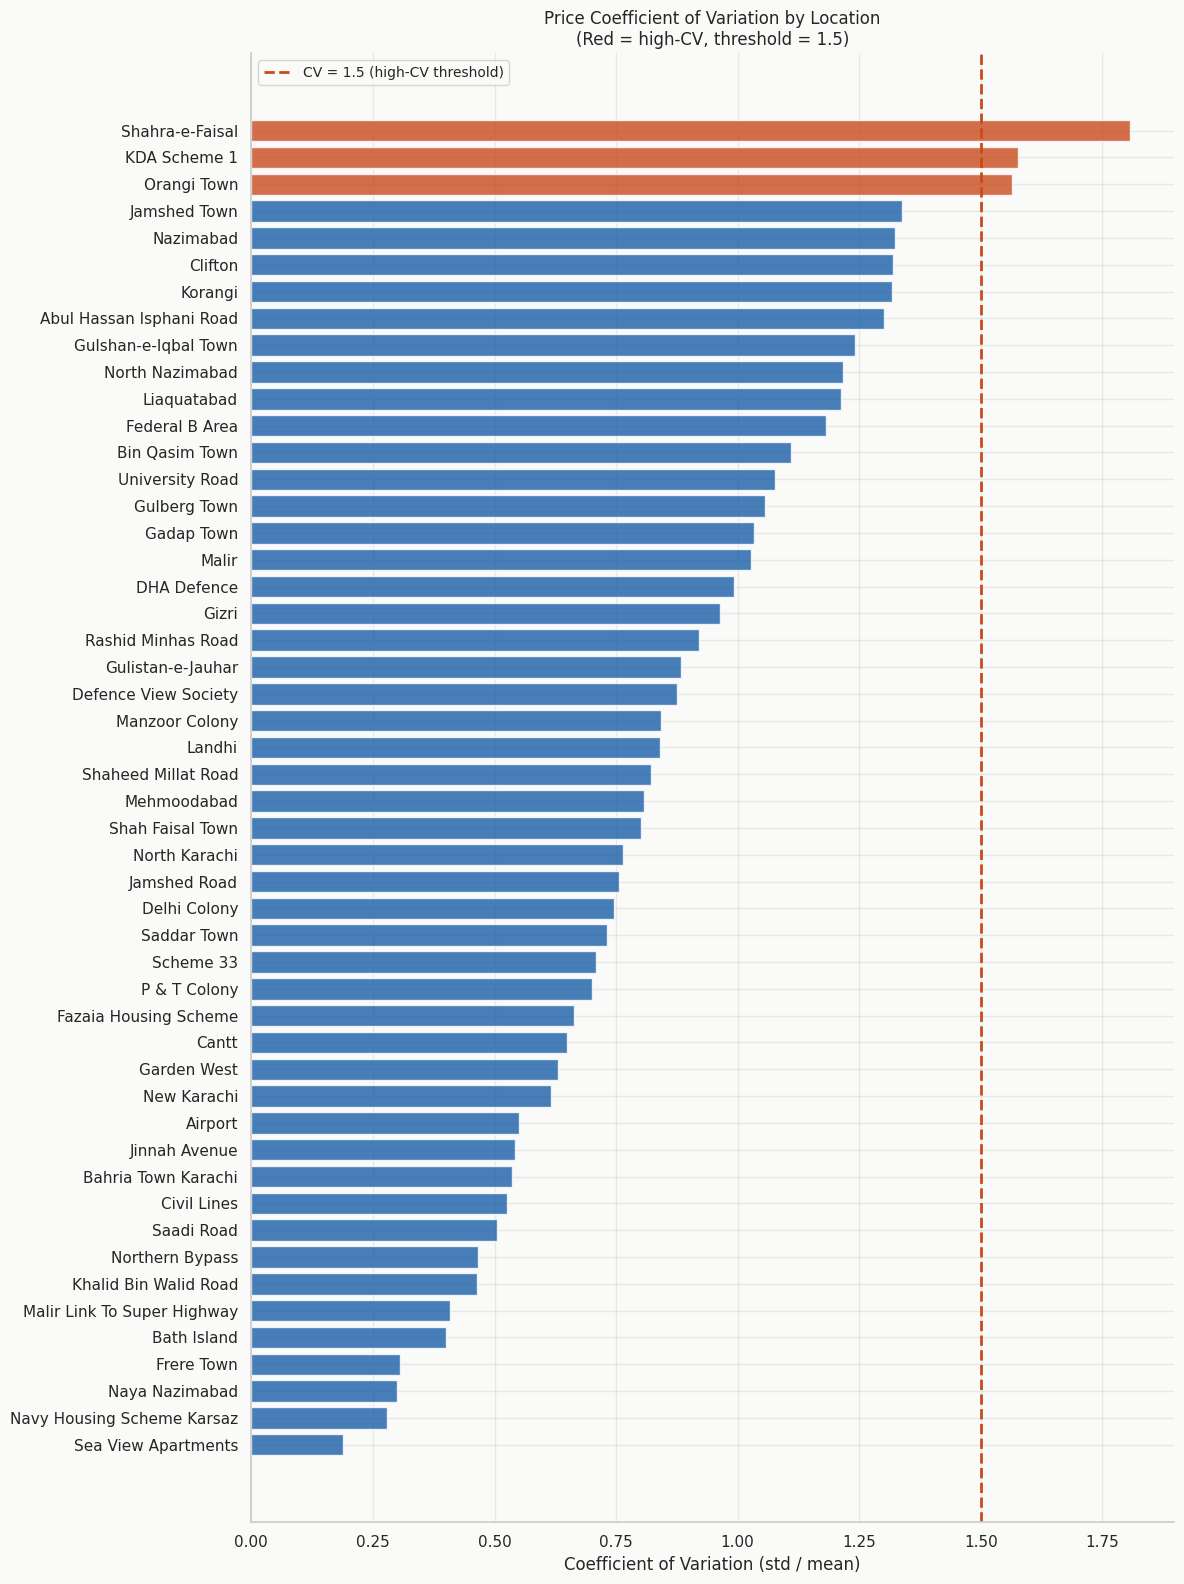

In [23]:
# 5.5 — Price coefficient of variation (CV) by location
# This directly motivates the location_price_cv and high_cv_location features in FE
loc_cv = (df.groupby('location')['price']
            .agg(lambda x: x.std() / (x.mean() + 1e-8))
            .reset_index()
            .rename(columns={'price': 'price_cv'})
            .sort_values('price_cv', ascending=False))

# Filter to locations with enough data
loc_cv = loc_cv[loc_cv['location'].isin(
    df['location'].value_counts()[lambda x: x >= 50].index
)]

fig, ax = plt.subplots(figsize=(12, max(5, len(loc_cv)*0.32)))
bars = ax.barh(loc_cv['location'][::-1], loc_cv['price_cv'][::-1],
               color=[ACCENT if v > 1.5 else BLUE for v in loc_cv['price_cv'][::-1]],
               alpha=0.8, edgecolor='white')
ax.axvline(1.5, color=ACCENT, linestyle='--', lw=2, label='CV = 1.5 (high-CV threshold)')
ax.set_xlabel('Coefficient of Variation (std / mean)')
ax.set_title('Price Coefficient of Variation by Location\n(Red = high-CV, threshold = 1.5)',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/eda_bi_price_cv_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
high_cv_locs = loc_cv[loc_cv['price_cv'] > 1.5]
print(f"Locations with price CV > 1.5: {len(high_cv_locs)}")
print(high_cv_locs[['location','price_cv']].to_string(index=False))

print("Among locations with at least 50 listings, three locations exceed the high-variability threshold (CV > 1.5): Shahra-e-Faisal, KDA Scheme 1, and Orangi Town.")
print("Feature Engineering later computes CV on the full training dataset and may identify additional high-CV locations with smaller sample sizes.")

Locations with price CV > 1.5: 3
       location  price_cv
Shahra-e-Faisal  1.806767
   KDA Scheme 1  1.575600
    Orangi Town  1.563987
Among locations with at least 50 listings, three locations exceed the high-variability threshold (CV > 1.5): Shahra-e-Faisal, KDA Scheme 1, and Orangi Town.
Feature Engineering later computes CV on the full training dataset and may identify additional high-CV locations with smaller sample sizes.


<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Price per sqft varies widely across locations</b>, from about PKR 3,300/sqft in the cheapest areas to over PKR 22,000/sqft in DHA Defence, the most expensive. This confirms that <b>all price comparisons must be done within location groups</b>, not globally. This is the core motivation for every group-wise feature.</li>
<li>The overall <b>Pearson correlation between price and area is weak (r = 0.11)</b>, primarily because location-driven price differences dominate. Within individual top locations, the Spearman correlation between price and area ranges from about 0.52 to 0.91, confirming that location must be controlled for in any price model.</li>
<li><b>Bedroom premium is location-dependent.</b> Among the top 5 locations charted (Bahria Town Karachi, DHA Defence, Gulistan-e-Jauhar, Gulshan-e-Iqbal Town, Gadap Town), DHA Defence shows by far the steepest price increase per extra bedroom, while Gulistan-e-Jauhar stays comparatively flat. This justifies the <b>price_vs_expected_ratio</b> (price vs median for the same location and bedroom combination) in FE.</li>
<li><b>Price CV varies across locations.</b> The three most volatile locations (Shahra-e-Faisal, KDA Scheme 1, and Orangi Town) all exceed the 1.5 threshold, reaching as high as 1.8. These high-CV areas produce the <b>high_cv_location flag</b> in FE.</li>
</ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>6. Outlier Analysis</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Measure the scale of price and area outliers in the cleaned dataset. Outliers are not removed here, since in this anomaly detection project they are treated as fraud signals, not noise.
</b></i></p>
<hr>

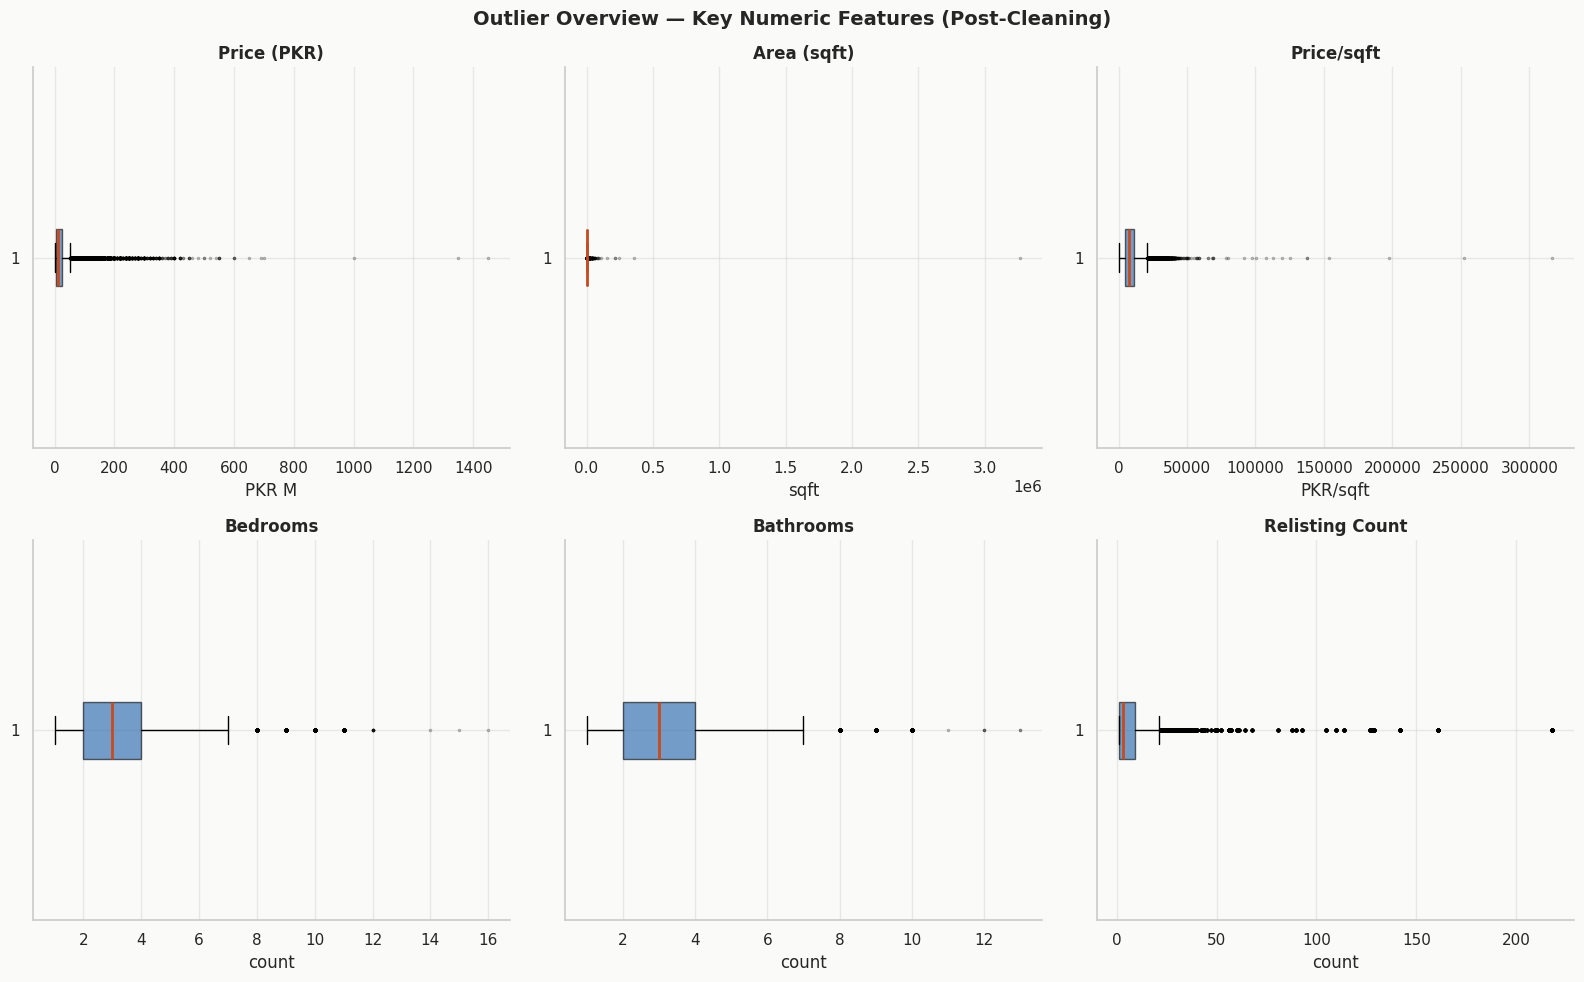

In [25]:
# 6.1 — Box plots for key numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Outlier Overview — Key Numeric Features (Post-Cleaning)', fontsize=14, fontweight='bold')

features = [
    ('price',           'Price (PKR)', 1e6,    'PKR M'),
    ('area_sqft',       'Area (sqft)', 1,       'sqft'),
    ('price_per_sqft',  'Price/sqft',  1,       'PKR/sqft'),
    ('bedrooms',        'Bedrooms',    1,       'count'),
    ('baths',           'Bathrooms',   1,       'count'),
    ('relisting_count', 'Relisting Count', 1,   'count'),
]

for ax, (col, title, divisor, unit) in zip(axes.flatten(), features):
    if col == 'price_per_sqft':
        data = price_per_sqft / divisor
    else:
        data = df[col] / divisor
    ax.boxplot(data, vert=False, patch_artist=True,
               boxprops=dict(facecolor=BLUE, alpha=0.6),
               medianprops=dict(color=ACCENT, linewidth=2),
               flierprops=dict(marker='.', color=ACCENT, alpha=0.3, markersize=3))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(unit)

plt.tight_layout()
plt.savefig('reports/figures/eda_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# 6.2 — IQR-based outlier counts per feature
print("IQR-based outlier analysis (values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR):")
print()
print(f"{'Feature':<25} {'Q1':>12} {'Median':>12} {'Q3':>12} {'IQR':>12} {'Lower':>12} {'Upper':>12} {'Outliers':>10} {'Rate':>8}")
print("-" * 118)

for col in ['price', 'area_sqft', 'price_per_sqft', 'bedrooms', 'baths', 'relisting_count']:
    if col == 'price_per_sqft':
        series = price_per_sqft
    else:
        series = df[col]

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = ((series < lo) | (series > hi)).sum()
    pct   = n_out / len(df) * 100
    print(f"  {col:<23} {q1:>12,.1f} {series.median():>12,.1f} {q3:>12,.1f} {iqr:>12,.1f} {lo:>12,.1f} {hi:>12,.1f} {n_out:>10,} {pct:>7.1f}%")


IQR-based outlier analysis (values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR):

Feature                             Q1       Median           Q3          IQR        Lower        Upper   Outliers     Rate
----------------------------------------------------------------------------------------------------------------------
  price                    6,500,000.0 12,500,000.0 25,000,000.0 18,500,000.0 -21,250,000.0 52,750,000.0      5,526    11.8%
  area_sqft                    1,143.5      1,633.5      2,613.6      1,470.1     -1,061.8      4,818.8      4,153     8.9%
  price_per_sqft               5,043.4      7,269.7     11,478.4      6,435.1     -4,609.2     21,131.0      2,411     5.2%
  bedrooms                         2.0          3.0          4.0          2.0         -1.0          7.0      1,018     2.2%
  baths                            2.0          3.0          4.0          2.0         -1.0          7.0        974     2.1%
  relisting_count                  1.0          3.0          9

In [27]:
# 6.3 — Extreme price listings: are they suspicious?
# This validates that price outliers are disproportionately flagged as suspicious
p99_price = df['price'].quantile(0.99)
p01_price = df['price'].quantile(0.01)

extreme_high = df[df['price'] > p99_price]
extreme_low  = df[df['price'] < p01_price]
normal       = df[(df['price'] >= p01_price) & (df['price'] <= p99_price)]

print("Suspicious rate by price tier:")
print(f"  Top 1% price   (>{p99_price/1e6:.1f}M): {extreme_high['is_suspicious'].mean()*100:.1f}%  ({len(extreme_high):,} listings)")
print(f"  Bottom 1% price (<{p01_price/1e6:.2f}M): {extreme_low['is_suspicious'].mean()*100:.1f}%  ({len(extreme_low):,} listings)")
print(f"  Normal range    : {normal['is_suspicious'].mean()*100:.1f}%  ({len(normal):,} listings)")

Suspicious rate by price tier:
  Top 1% price   (>201.7M): 4.5%  (467 listings)
  Bottom 1% price (<1.50M): 58.6%  (437 listings)
  Normal range    : 9.1%  (45,763 listings)


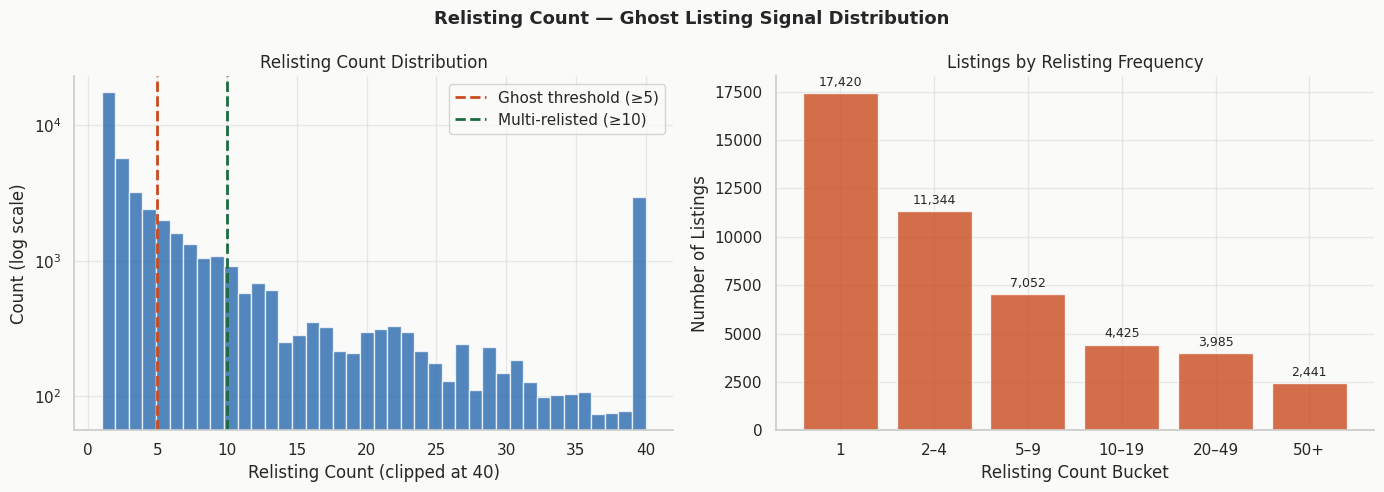

Max relisting count: 218
Ghost listings (≥5) : 17,903  (38.4%)
Multi-relisted (≥10): 10,851  (23.3%)


In [28]:
# 6.4 — Relisting count distribution (key ghost listing signal)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relisting Count — Ghost Listing Signal Distribution', fontsize=13, fontweight='bold')

axes[0].hist(df['relisting_count'].clip(upper=40), bins=40,
             color=BLUE, alpha=0.75, edgecolor='white', log=True)
axes[0].axvline(5, color=ACCENT, linestyle='--', lw=2, label='Ghost threshold (≥5)')
axes[0].axvline(10, color=GREEN, linestyle='--', lw=2, label='Multi-relisted (≥10)')
axes[0].set_xlabel('Relisting Count (clipped at 40)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Relisting Count Distribution')
axes[0].legend()

relisting_bins = [1, 2, 5, 10, 20, 50, df['relisting_count'].max()+1]
labels = ['1', '2–4', '5–9', '10–19', '20–49', '50+']
binned = pd.cut(df['relisting_count'], bins=relisting_bins, labels=labels, right=False)
vc = binned.value_counts().sort_index()
bars = axes[1].bar(vc.index, vc.values, color=ACCENT, alpha=0.8, edgecolor='white')
axes[1].bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
axes[1].set_xlabel('Relisting Count Bucket')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Listings by Relisting Frequency')

plt.tight_layout()
plt.savefig('reports/figures/eda_outlier_relisting.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max relisting count: {df['relisting_count'].max()}")
print(f"Ghost listings (≥5) : {(df['relisting_count']>=5).sum():,}  ({(df['relisting_count']>=5).mean()*100:.1f}%)")
print(f"Multi-relisted (≥10): {(df['relisting_count']>=10).sum():,}  ({(df['relisting_count']>=10).mean()*100:.1f}%)")

<h4 style="font-family: Arial;"><b>Key Observations :</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Price outliers are not uniformly suspicious.</b> Listings in the bottom 1% of price are far more likely to be flagged suspicious (58.6%) than the normal price range (9.1%). Listings in the top 1% of price are actually flagged suspicious less often (4.5%) than normal-priced listings. This shows price_too_low_flag is a much stronger fraud signal than price_very_high_flag.</li>
<li><b>IQR bounds from this section directly set the clip_limits</b> in FE. The clipping is not arbitrary, it is informed by the quartile ranges seen here.</li>
<li><b>Relisting_count has an extreme tail</b> (some listings reposted over 200 times, max 218). This massive range makes the raw count unusable as a model feature, log1p compression (producing relisting_intensity in FE Section 9) is confirmed as the correct transformation.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>7. Anomaly Flag Analysis (Target Variable)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Profile what suspicious listings look like, including their location, property type, price range, and relisting behaviour, based on the four flags that make up is_suspicious.
</b></i></p>
<hr>

In [29]:
# 7.1 — Suspicious vs clean: high-level profile comparison
sus   = df[df['is_suspicious'] == 1]
clean = df[df['is_suspicious'] == 0]

print("Suspicious vs Clean Listing Profile:")
print(f"{'Metric':<30} {'Clean':>15} {'Suspicious':>15} {'Ratio':>10}")
print("-" * 75)

metrics = [
    ('Count',                    len(clean),                      len(sus)),
    ('Median Price (M PKR)',      clean['price'].median()/1e6,     sus['price'].median()/1e6),
    ('Median Area (sqft)',        clean['area_sqft'].median(),      sus['area_sqft'].median()),
    ('Median Price/sqft',        price_per_sqft.loc[clean.index].median(),  price_per_sqft.loc[sus.index].median()),
    ('Median Bedrooms',           clean['bedrooms'].median(),       sus['bedrooms'].median()),
    ('Median Relisting Count',    clean['relisting_count'].median(),sus['relisting_count'].median()),
    ('Mean Relisting Count',      clean['relisting_count'].mean(),  sus['relisting_count'].mean()),
]

for label, c_val, s_val in metrics:
    ratio = s_val / c_val if c_val != 0 else float('inf')
    print(f"  {label:<28} {c_val:>15.2f} {s_val:>15.2f} {ratio:>10.2f}x")

Suspicious vs Clean Listing Profile:
Metric                                   Clean      Suspicious      Ratio
---------------------------------------------------------------------------
  Count                               42204.00         4463.00       0.11x
  Median Price (M PKR)                   12.80           10.60       0.83x
  Median Area (sqft)                   1633.50         1633.50       1.00x
  Median Price/sqft                    7441.61         6074.73       0.82x
  Median Bedrooms                         3.00            3.00       1.00x
  Median Relisting Count                  2.00            8.00       4.00x
  Mean Relisting Count                   10.97           14.84       1.35x


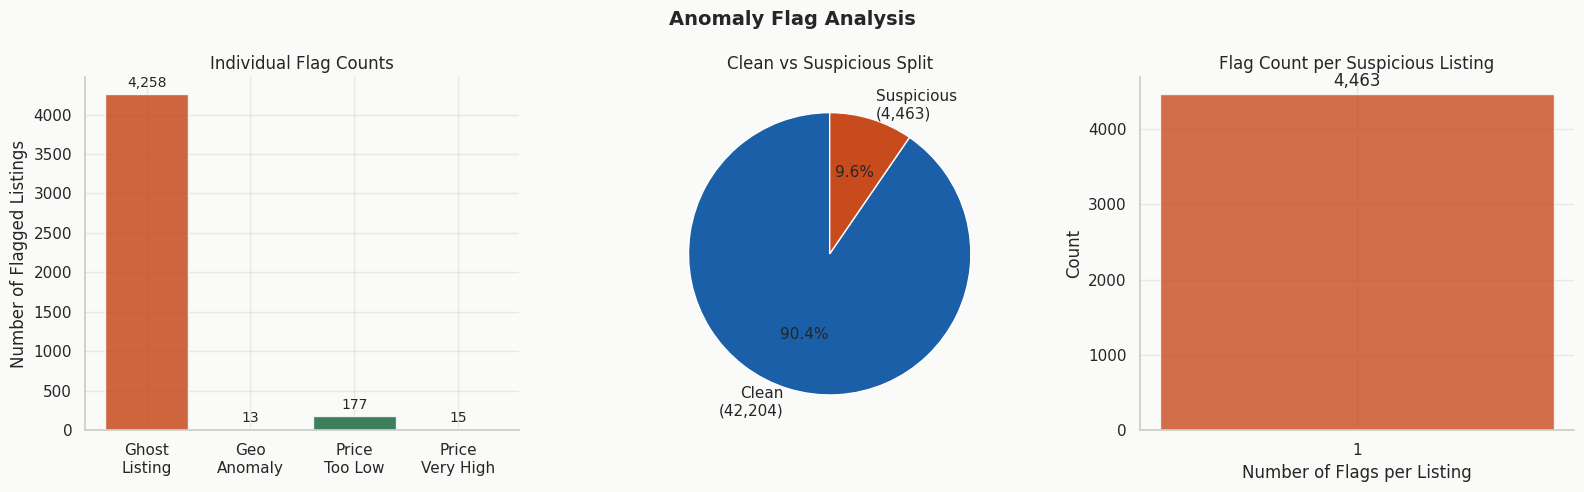

In [30]:
# 7.2 — Flag breakdown and co-occurrence
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Anomaly Flag Analysis', fontsize=14, fontweight='bold')

# Flag counts
flag_cols = ['ghost_listing_flag', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag']
flag_labels = ['Ghost\nListing', 'Geo\nAnomaly', 'Price\nToo Low', 'Price\nVery High']
flag_counts = [df[f].sum() for f in flag_cols]
bars = axes[0].bar(flag_labels, flag_counts, color=[ACCENT, BLUE, GREEN, AMBER], alpha=0.85)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=10)
axes[0].set_ylabel('Number of Flagged Listings')
axes[0].set_title('Individual Flag Counts')

# Clean vs suspicious pie
sizes = [len(clean), len(sus)]
axes[1].pie(sizes, labels=[f'Clean\n({sizes[0]:,})', f'Suspicious\n({sizes[1]:,})'],
            colors=[BLUE, ACCENT], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Clean vs Suspicious Split')

# Flag co-occurrence in suspicious set
flag_combo = sus[flag_cols].sum(axis=1).value_counts().sort_index()
bars3 = axes[2].bar(flag_combo.index.astype(str), flag_combo.values, color=ACCENT, alpha=0.8)
axes[2].bar_label(bars3, fmt='{:,.0f}', padding=3)
axes[2].set_xlabel('Number of Flags per Listing')
axes[2].set_ylabel('Count')
axes[2].set_title('Flag Count per Suspicious Listing')

plt.tight_layout()
plt.savefig('reports/figures/eda_anomaly_flags.png', dpi=150, bbox_inches='tight')
plt.show()

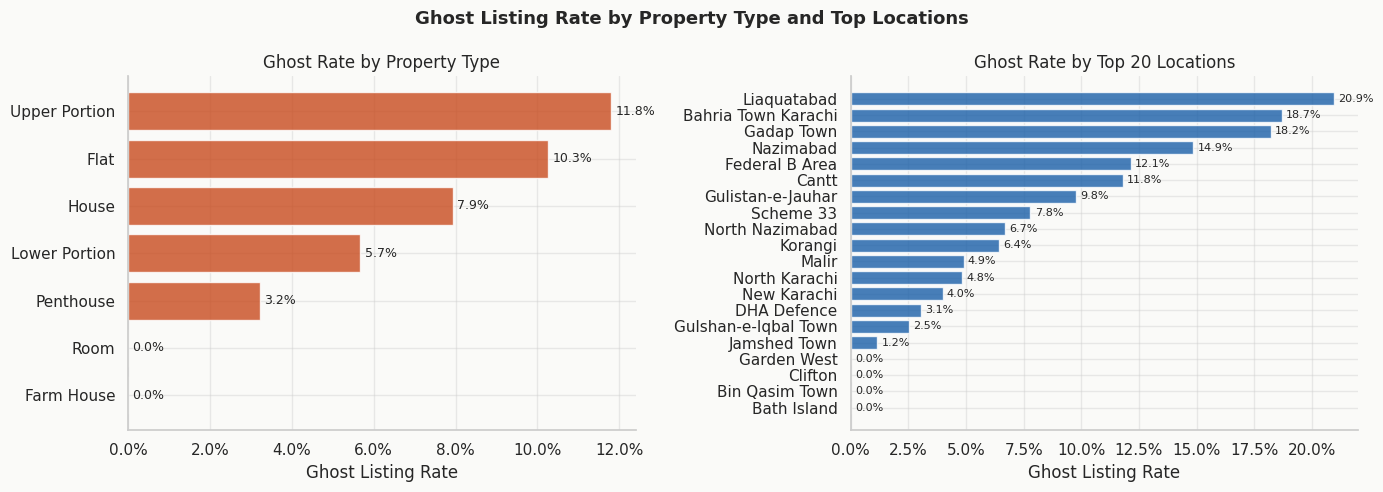

In [31]:
# 7.3 — Ghost listing rate by property type and location
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ghost Listing Rate by Property Type and Top Locations', fontsize=13, fontweight='bold')

# By property type
ghost_by_type = (df.groupby('property_type')['ghost_listing_flag']
                   .mean()
                   .sort_values(ascending=True))
bars = axes[0].barh(ghost_by_type.index, ghost_by_type.values, color=ACCENT, alpha=0.8)
axes[0].bar_label(bars, fmt='{:.1%}', padding=3, fontsize=9)
axes[0].set_xlabel('Ghost Listing Rate')
axes[0].set_title('Ghost Rate by Property Type')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# By location (top 15 reliable locations)
top_locs = df['location'].value_counts().head(20).index
ghost_by_loc = (df[df['location'].isin(top_locs)]
                .groupby('location')['ghost_listing_flag']
                .mean()
                .sort_values(ascending=True))
bars2 = axes[1].barh(ghost_by_loc.index, ghost_by_loc.values, color=BLUE, alpha=0.8)
axes[1].bar_label(bars2, fmt='{:.1%}', padding=3, fontsize=8)
axes[1].set_xlabel('Ghost Listing Rate')
axes[1].set_title('Ghost Rate by Top 20 Locations')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('reports/figures/eda_ghost_rate_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


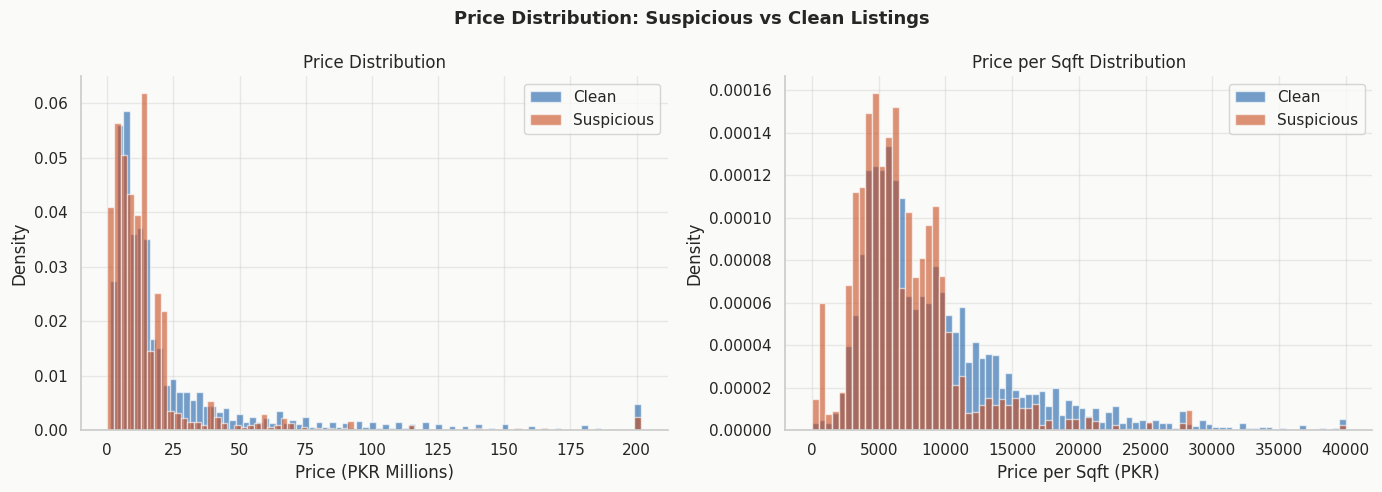

In [32]:
# 7.4 — Price distribution: suspicious vs clean overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution: Suspicious vs Clean Listings', fontsize=13, fontweight='bold')

max_price = df['price'].quantile(0.99)

axes[0].hist(clean['price'].clip(upper=max_price) / 1e6, bins=80,
             color=BLUE, alpha=0.6, label='Clean', density=True)
axes[0].hist(sus['price'].clip(upper=max_price) / 1e6, bins=80,
             color=ACCENT, alpha=0.6, label='Suspicious', density=True)
axes[0].set_xlabel('Price (PKR Millions)')
axes[0].set_ylabel('Density')
axes[0].set_title('Price Distribution')
axes[0].legend()

axes[1].hist(price_per_sqft.loc[clean.index].clip(upper=40000), bins=80,
             color=BLUE, alpha=0.6, label='Clean', density=True)
axes[1].hist(price_per_sqft.loc[sus.index].clip(upper=40000), bins=80,
             color=ACCENT, alpha=0.6, label='Suspicious', density=True)
axes[1].set_xlabel('Price per Sqft (PKR)')
axes[1].set_ylabel('Density')
axes[1].set_title('Price per Sqft Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/eda_price_suspicious_vs_clean.png', dpi=150, bbox_inches='tight')
plt.show()

<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Suspicious listings have a much higher median relisting count</b> than clean listings (8 vs 2, a 4x difference). The mean values are closer (14.84 vs 10.97) because a few heavily relisted clean listings pull the clean average up. This still supports relisting_count, relisting_intensity (log-transformed), and is_multi_relisted as important <b>relisting features in FE Section 9</b>.</li>
<li><b>Ghost listing rates differ by location and property type.</b> Some areas show 2–3x
higher ghost rates than others. The model must therefore receive both the relisting signal
AND location context to correctly interpret it.</li>
<li><b>Price distributions overlap substantially</b> between suspicious and clean listings
at the median. This is expected — most suspicious listings use realistic-looking prices
to appear legitimate. It confirms that price alone is insufficient for detection and
that <b>relative deviation features</b> (z-scores, IQR deviations vs the local norm)
are essential additions.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>8. Temporal Analysis</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Analyse listing volume over time and across the week. Volume spikes in a location/week combination are a strong ghost listing signal, since legitimate sellers list once but fraudsters repost repeatedly.
</b></i></p>
<hr>

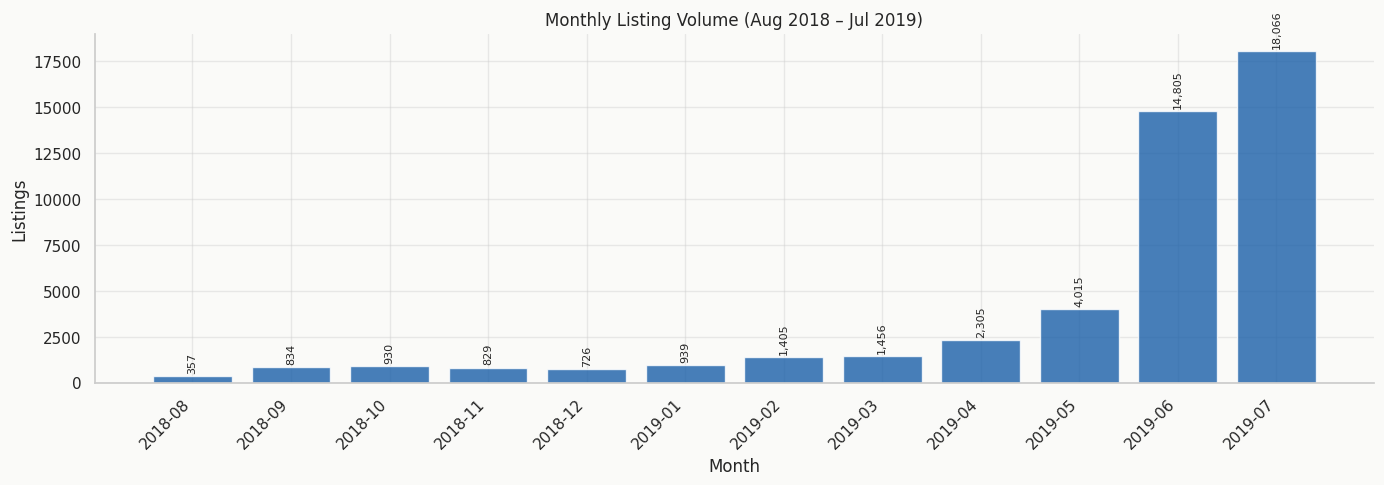

In [33]:
# 8.1 — Monthly listing volume overall

monthly = (df['date_added'].dt.to_period('M')
           .value_counts()
           .sort_index()
           .reset_index())
monthly.columns = ['year_month', 'count']
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly['year_month_str'], monthly['count'], color=BLUE, alpha=0.8, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=2, fontsize=8, rotation=90)
ax.set_xlabel('Month')
ax.set_ylabel('Listings')
ax.set_title('Monthly Listing Volume (Aug 2018 – Jul 2019)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/eda_temporal_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()


Weekend listings (Sat+Sun): 6,939  (14.9%)
Weekday listings          : 39,728  (85.1%)


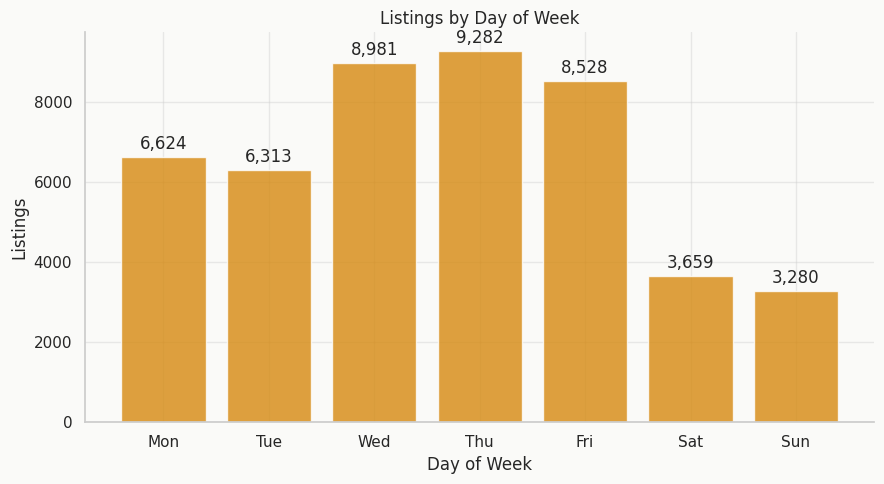

In [34]:
# 8.2 — Day-of-week listing distribution

dow_counts = df['date_added'].dt.dayofweek.value_counts().sort_index()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dow_labels, dow_counts.values, color=AMBER, alpha=0.8, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Listings')
ax.set_title('Listings by Day of Week', fontsize=12)

weekend_count = dow_counts[[5,6]].sum()
weekday_count = dow_counts[[0,1,2,3,4]].sum()
print(f"Weekend listings (Sat+Sun): {weekend_count:,}  ({weekend_count/len(df)*100:.1f}%)")
print(f"Weekday listings          : {weekday_count:,}  ({weekday_count/len(df)*100:.1f}%)")

plt.tight_layout()
plt.savefig('reports/figures/eda_temporal_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# 8.3 — Weekly volume spikes by location
# Compute listings per week per location
wk_vol=df.groupby([ df['date_added'].dt.to_period('W').astype(str), 'location']).size().reset_index(name='week_count')

avg_weekly = wk_vol.groupby('location')['week_count'].mean().reset_index(name='avg_week')
wk_vol = wk_vol.merge(avg_weekly, on='location')
wk_vol['volume_ratio'] = wk_vol['week_count'] / (wk_vol['avg_week'] + 1e-8)

spike_weeks = wk_vol[wk_vol['volume_ratio'] > 3]

print(f"Location-week combinations with volume > 3x average: {len(spike_weeks):,}")
print(f"  ({len(spike_weeks)/len(wk_vol)*100:.1f}% of all location-week pairs)")
print()
print("Top 10 spike events (location, week, ratio):")
top_spikes = spike_weeks.sort_values('volume_ratio', ascending=False).head(10)
for _, row in top_spikes.iterrows():
    print(f"  {row['location']:<30} Week: {row['date_added']}  Volume: {row['week_count']:>4}  Ratio: {row['volume_ratio']:.1f}×")


Location-week combinations with volume > 3x average: 75
  (3.9% of all location-week pairs)

Top 10 spike events (location, week, ratio):
  Fazaia Housing Scheme          Week: 2019-05-06/2019-05-12  Volume:  116  Ratio: 12.2×
  Malir Link To Super Highway    Week: 2019-06-24/2019-06-30  Volume:   43  Ratio: 8.4×
  Northern Bypass                Week: 2019-05-06/2019-05-12  Volume:   58  Ratio: 7.7×
  Bahria Town Karachi            Week: 2019-07-01/2019-07-07  Volume: 1874  Ratio: 7.1×
  Airport                        Week: 2019-06-24/2019-06-30  Volume:   40  Ratio: 7.0×
  Jinnah Avenue                  Week: 2019-06-24/2019-06-30  Volume:   49  Ratio: 6.2×
  North Karachi                  Week: 2019-07-01/2019-07-07  Volume:  452  Ratio: 5.7×
  Bahria Town Karachi            Week: 2019-06-24/2019-06-30  Volume: 1508  Ratio: 5.7×
  Jamshed Road                   Week: 2019-07-15/2019-07-21  Volume:   44  Ratio: 5.7×
  Saadi Road                     Week: 2019-07-08/2019-07-14  Volume:

<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Dramatic volume spikes exist in specific months.</b> Listings jump from about 4,200 in May 2019 to about 14,800 in June and 18,200 in July 2019. This is almost certainly a bulk scraping/data collection event,
not a real market surge. The model needs to contextualise this through the
<b>weekly_volume_ratio</b> feature, which normalises volume against each location's own average.</li>
<li><b>Listing volume is not uniform across the week.</b> Weekend listings (Saturday and Sunday) make up only 14.9% of the total, well below the 28.6% you would expect if postings were spread evenly across all seven days. Listings are concentrated on weekdays, which the <b>is_weekend flag</b> captures for FE.</li>
<li><b>Location-week volume spikes are rare but concentrated.</b>
Only ~4% of location-week pairs show volume > 3× average. The <b>weekly_volume_ratio</b> is a high-precision signal for these spikes.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>9. Bath-to-Bedroom Ratio Analysis</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Find the typical bath-to-bedroom ratio for Karachi properties and flag listings with implausible ratios, which motivates the bath_bed_ratio and bath_bed_extreme features in FE.
</b></i></p>

<hr>

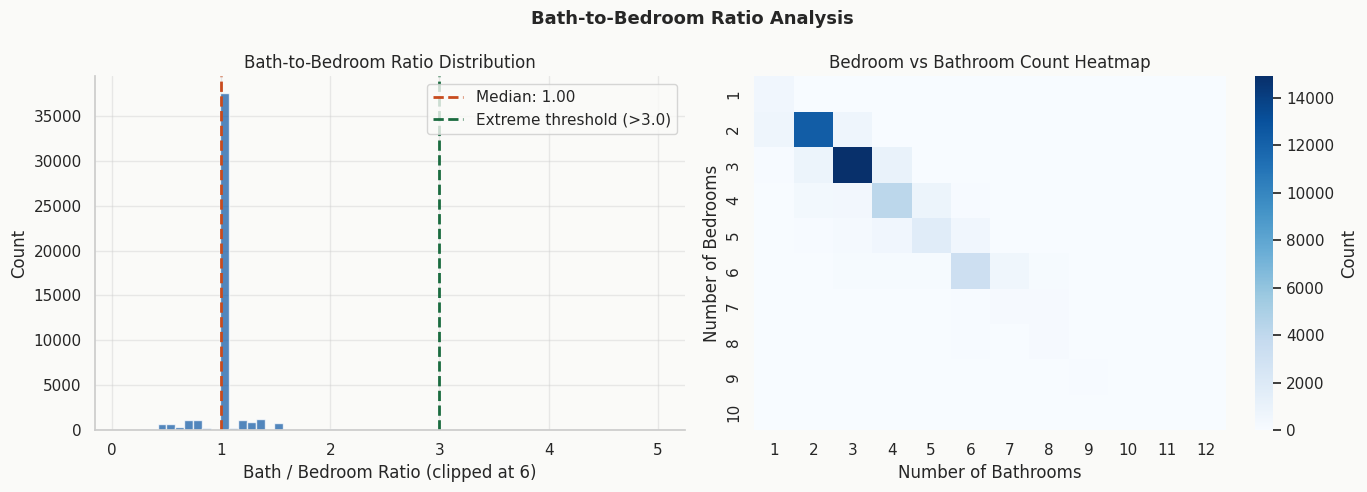

In [36]:
# 9.1 — Compute and visualise bath/bedroom ratio
bath_bed_ratio = df['baths'] / (df['bedrooms'] + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bath-to-Bedroom Ratio Analysis', fontsize=13, fontweight='bold')

axes[0].hist(bath_bed_ratio.clip(0, 6), bins=60, color=BLUE, alpha=0.75, edgecolor='white')
axes[0].axvline(bath_bed_ratio.median(), color=ACCENT, linestyle='--', lw=2,
                label=f"Median: {bath_bed_ratio.median():.2f}")
axes[0].axvline(3.0, color=GREEN, linestyle='--', lw=2, label='Extreme threshold (>3.0)')
axes[0].set_xlabel('Bath / Bedroom Ratio (clipped at 6)')
axes[0].set_ylabel('Count')
axes[0].set_title('Bath-to-Bedroom Ratio Distribution')
axes[0].legend()

# Heatmap of bedroom vs bath counts
bed_bath_pivot = (df.groupby(['bedrooms','baths'])
                    .size()
                    .unstack(fill_value=0))
bed_bath_pivot = bed_bath_pivot.loc[
    bed_bath_pivot.index[bed_bath_pivot.index <= 10],
    bed_bath_pivot.columns[bed_bath_pivot.columns <= 12]
]

sns.heatmap(bed_bath_pivot, annot=False, cmap='Blues', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Bedroom vs Bathroom Count Heatmap')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Number of Bedrooms')

plt.tight_layout()
plt.savefig('reports/figures/eda_bath_bed_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
extreme_mask   = bath_bed_ratio > 3.0
normal_mask    = bath_bed_ratio <= 3.0
print(f"Listings with bath/bed ratio > 3.0: {extreme_mask.sum():,}  ({extreme_mask.mean()*100:.2f}%)")
print(f"Suspicious rate in extreme ratio listings: {df.loc[extreme_mask,  'is_suspicious'].mean()*100:.1f}%")
print(f"Suspicious rate in normal ratio listings : {df.loc[normal_mask, 'is_suspicious'].mean()*100:.1f}%")

Listings with bath/bed ratio > 3.0: 8  (0.02%)
Suspicious rate in extreme ratio listings: 0.0%
Suspicious rate in normal ratio listings : 9.6%


<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>The bath-to-bedroom ratio peaks tightly around 1.0–1.5</b> for normal Karachi residential properties.
Listings with ratio > 3.0 (e.g. 12 baths and 4 bedrooms) are physically implausible.
The <b>3.0 threshold used in FE</b> is confirmed by this distribution.</li>
<li><b>The bedroom vs bath heatmap shows a diagonal dominance</b> — most listings fall near the
1:1 diagonal (equal bedrooms and baths) or slightly above it. Listings far from this diagonal
are structurally unusual and are correctly flagged by bath_bed_extreme.</li>
<li><b>Extreme-ratio listings do not show a higher suspicious rate in this data</b> (0.0% vs 9.6%
for normal-ratio listings), but there are only 8 such listings in total, so this is too small a
sample to draw a conclusion from either way.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>10. Multivariate & Correlation Analysis</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Find the typical bath-to-bedroom ratio for Karachi properties and flag listings with implausible ratios, which motivates the bath_bed_ratio and bath_bed_extreme features in FE.
</b></i></p>

<hr>

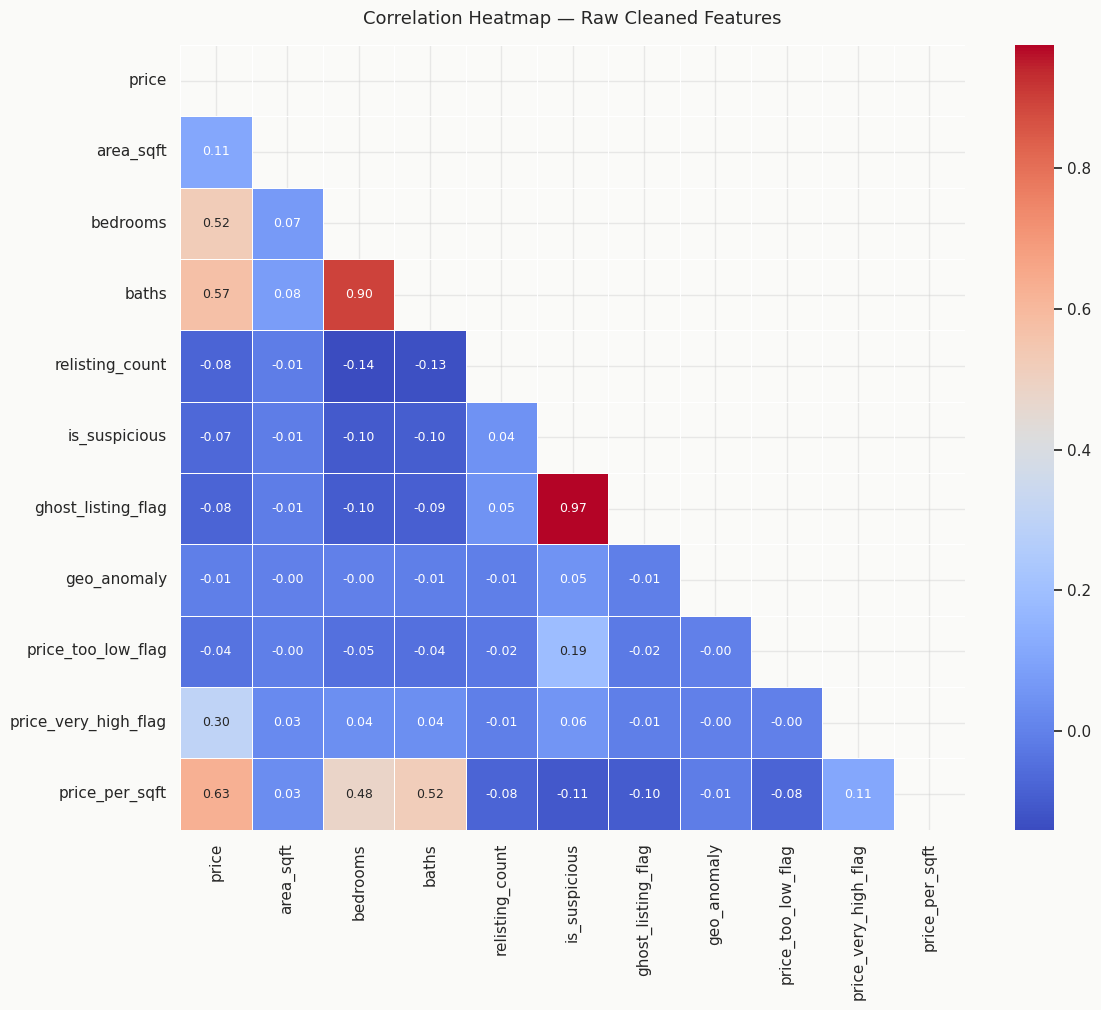

Highly correlated pairs (|r| > 0.7) among raw features:
  bedrooms <-> baths  r = 0.895
  is_suspicious <-> ghost_listing_flag  r = 0.974


In [38]:
# 10.1 — Correlation heatmap of raw numeric features
price_per_sqft = df['price'] / df['area_sqft']

# Define correlation columns (handle missing ones gracefully)
corr_cols = ['price', 'area_sqft', 'bedrooms', 'baths', 'relisting_count',
             'is_suspicious']

# Add flags only if they exist
for flag in ['ghost_listing_flag', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag']:
    if flag in df.columns:
        corr_cols.append(flag)

corr_df = df[corr_cols].copy()
corr_df['price_per_sqft'] = price_per_sqft
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, annot_kws={'size': 9}, square=True,
            linewidths=0.5)
ax.set_title('Correlation Heatmap — Raw Cleaned Features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('reports/figures/eda_multi_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high-correlation pairs
print("Highly correlated pairs (|r| > 0.7) among raw features:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}  r = {val:.3f}")

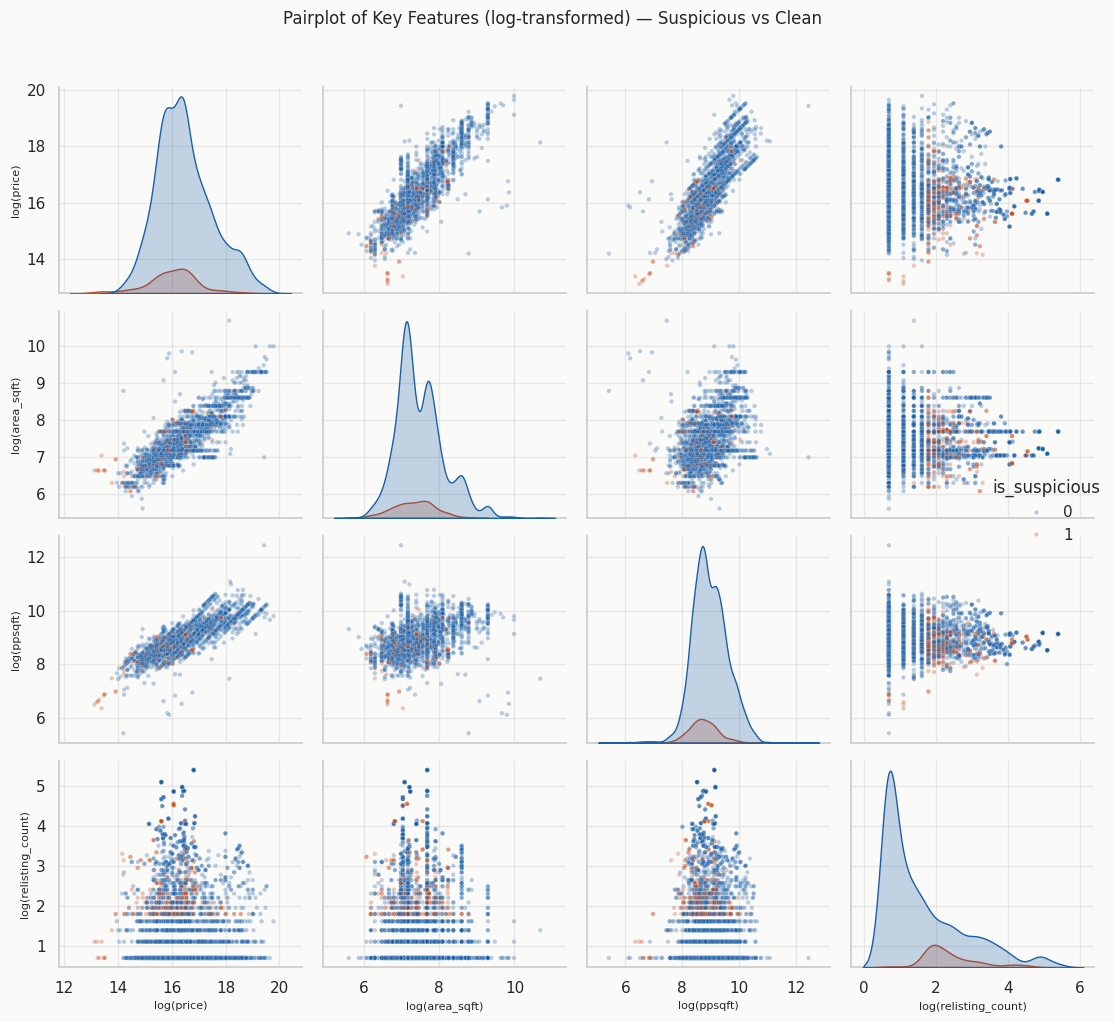

In [39]:
# 10.2 — Pair plot: price, area, ppsqft, relisting_count — coloured by is_suspicious
sample_corr = df.sample(n=min(3000, len(df)), random_state=42)
pair_cols = ['price', 'area_sqft', 'price_per_sqft', 'relisting_count']

# Build log-transformed data without mutating original df
log_data = pd.DataFrame({
    f'log_{col}': np.log1p(
        price_per_sqft if col == 'price_per_sqft' else sample_corr[col]
    ) for col in pair_cols
}, index=sample_corr.index)

log_data['is_suspicious'] = sample_corr['is_suspicious'].values

log_cols = [f'log_{c}' for c in pair_cols]
log_labels = ['log(price)', 'log(area_sqft)', 'log(ppsqft)', 'log(relisting_count)']

g = sns.pairplot(
    log_data,
    hue='is_suspicious',
    palette={0: BLUE, 1: ACCENT},
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde',
    vars=log_cols,
)

g.fig.suptitle('Pairplot of Key Features (log-transformed) — Suspicious vs Clean',
               y=1.02, fontsize=12)

# Rename axes
for ax_row, label in zip(g.axes, log_labels):
    ax_row[0].set_ylabel(label, fontsize=8)
for ax_col, label in zip(g.axes[-1], log_labels):
    ax_col.set_xlabel(label, fontsize=8)

plt.tight_layout()
plt.savefig('reports/figures/eda_multi_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

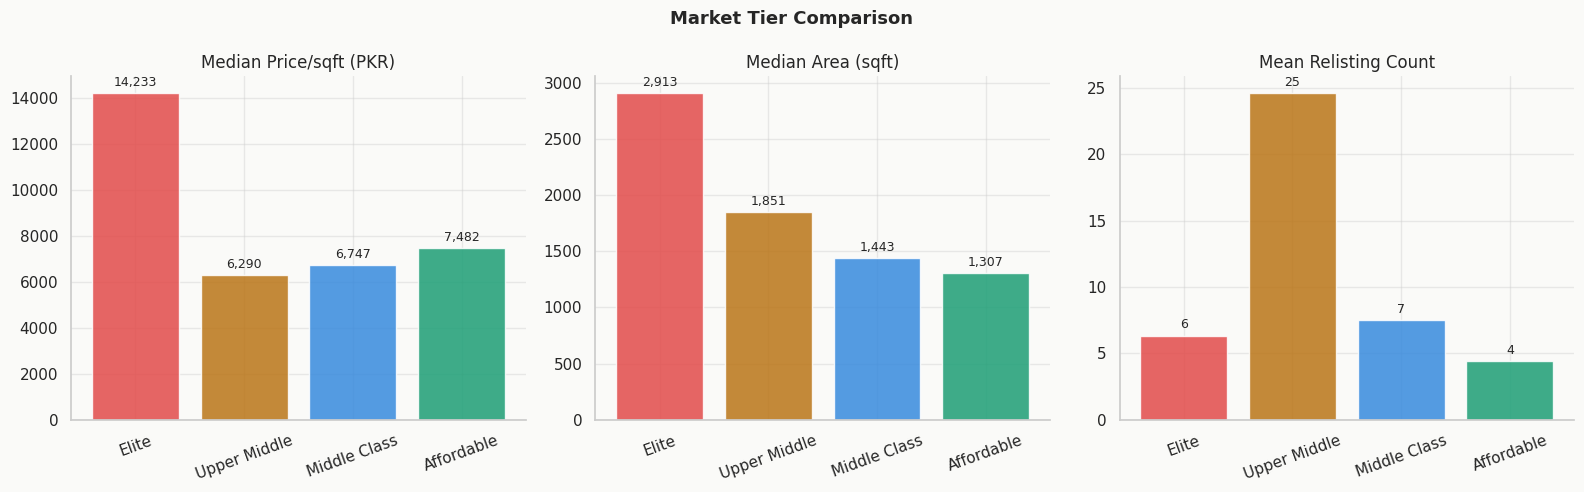

In [40]:
# 10.3 — Market tier comparison across key metrics
tier_order = ['Elite', 'Upper Middle', 'Middle Class', 'Affordable']

# Build a market_tier column using the same hardcoded map as the cleaning notebook
original_tier_map = {
    'DHA Defence':'Elite','Clifton':'Elite','Old Clifton':'Elite',
    'Bath Island':'Elite','Cantt':'Elite',
    'Bahria Town Karachi':'Upper Middle','Scheme 33':'Upper Middle',
    'Gulshan-e-Iqbal Town':'Upper Middle',
    'Gulistan-e-Jauhar':'Middle Class','North Nazimabad':'Middle Class',
    'Federal B Area':'Middle Class','Nazimabad':'Middle Class','Jamshed Town':'Middle Class',
    'Korangi':'Affordable','Liaquatabad':'Middle Class',
    'North Karachi':'Affordable','Malir':'Affordable',
}
market_tier = df['location'].map(original_tier_map).fillna('Other') if 'location' in df.columns else pd.Series(['Other'] * len(df), index=df.index)

tier_order = ['Elite', 'Upper Middle', 'Middle Class', 'Affordable']
tier_mask = market_tier.isin(tier_order)
tier_df = df[tier_mask].copy()
tier_df['market_tier'] = market_tier[tier_mask].values

# Add price_per_sqft temporarily for this analysis only
tier_df['price_per_sqft'] = price_per_sqft.loc[tier_df.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Market Tier Comparison', fontsize=13, fontweight='bold')

metrics_tier = [
    ('price_per_sqft', 'Median Price/sqft (PKR)'),
    ('area_sqft',      'Median Area (sqft)'),
    ('relisting_count','Mean Relisting Count'),
]

for ax, (col, title) in zip(axes, metrics_tier):
    if col == 'relisting_count':
        vals = tier_df.groupby('market_tier')[col].mean().reindex(tier_order)
    else:
        vals = tier_df.groupby('market_tier')[col].median().reindex(tier_order)
    bars = ax.bar(tier_order, vals.values,
                  color=[palette[t] for t in tier_order], alpha=0.85)
    ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('reports/figures/eda_multi_tier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Price and area_sqft are only weakly correlated (r ≈ 0.11)</b> as raw features.
However, in the feature set, they appear not as raw values but as <b>location-normalised
deviations</b> (price_loc_zscore, area_sqft_loc_zscore) — which have very different
correlation structure. Both are needed because they capture different aspects of anomaly.</li>
<li><b>Relisting count is weakly correlated with price and area</b> — confirming it adds
independent information that price/area features alone cannot capture.
Ghost listings are spread across all price tiers, not concentrated in cheap properties.</li>
<li><b>The market tier structure is clear and stable</b> across all three metrics.
Elite areas have 2–3x higher price/sqft, and surprisingly similar relisting rates,
suggesting that ghost listing fraud is not limited to low-end markets.
This validates including <b>both market_tier features</b> as model inputs in FE.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>11. Geographic Distribution Analysis</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color: black;"><i><b>
Goal: Map listings by price and by suspicious status to see whether location drives value and whether fraud clusters in specific areas.
</b></i></p>
<hr>

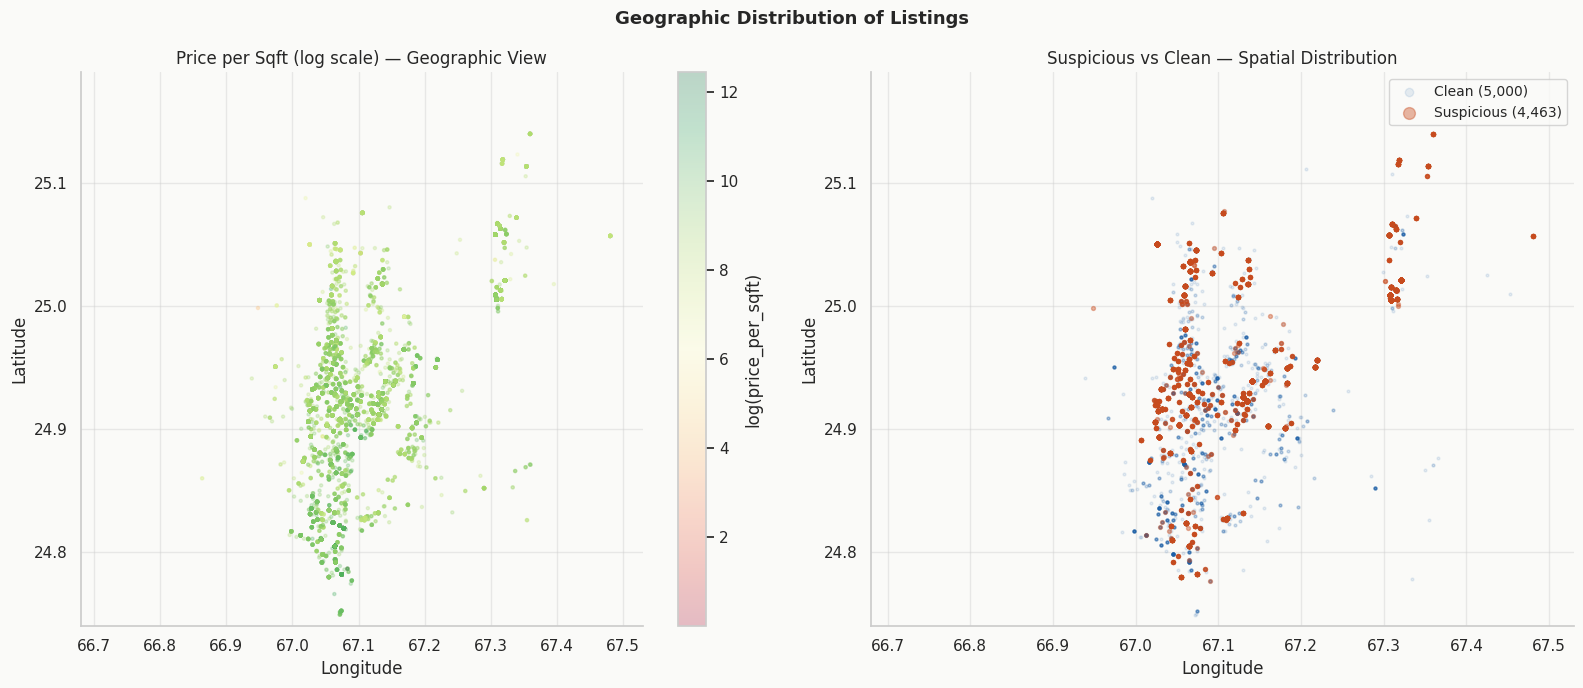

In [41]:
# 11.1 — Scatter map of all listings coloured by price tier
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Geographic Distribution of Listings', fontsize=13, fontweight='bold')

# Price per sqft geographic scatter
scatter_data = df.sample(n=min(10000, len(df)), random_state=42)
sc = axes[0].scatter(
    scatter_data['longitude'], scatter_data['latitude'],
    c=np.log1p(price_per_sqft.loc[scatter_data.index]),
    cmap='RdYlGn', alpha=0.25, s=5
)
plt.colorbar(sc, ax=axes[0], label='log(price_per_sqft)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Price per Sqft (log scale) — Geographic View')
axes[0].set_xlim(66.68, 67.53)
axes[0].set_ylim(24.74, 25.19)

# Suspicious vs clean geographic scatter
clean_s = df[df['is_suspicious']==0].sample(n=min(5000, (df['is_suspicious']==0).sum()), random_state=42)
sus_s   = df[df['is_suspicious']==1]

axes[1].scatter(clean_s['longitude'], clean_s['latitude'],
                alpha=0.1, s=4, color=BLUE, label=f'Clean ({len(clean_s):,})')
axes[1].scatter(sus_s['longitude'], sus_s['latitude'],
                alpha=0.4, s=8, color=ACCENT, label=f'Suspicious ({len(sus_s):,})')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Suspicious vs Clean — Spatial Distribution')
axes[1].set_xlim(66.68, 67.53)
axes[1].set_ylim(24.74, 25.19)
axes[1].legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.savefig('reports/figures/eda_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Price clusters geographically</b> Elite areas along the southern coastal belt
(DHA, Clifton, Cantt) vs middle-class inland areas is clearly visible.
This spatial pattern is <b>captured by location_enc and market_tier features in FE</b>,
not by raw lat/lon values (which would suffer from geo_anomaly noise).</li>
<li><b>Suspicious listings are geographically distributed across all areas</b>, not concentrated
in any single zone. This confirms that fraud is market-wide and that
<b>location-relative features</b> (z-scores, IQR deviations computed within each location group)
are necessary (a suspicious listing in DHA looks different from one in Korangi when
measured against its local peers).</li>
</i></ul>